# **Project Title**
## Sentiment Analysis and Topic Modeling of Google Play Store Reviews



# **Author Names:**
  - Muhammad Salman Saleem (fa24-bbd-101)  
  - Mehak Fatima (fa24-bbd-049)  
  - Amna Nawaz Gondal (fa24-bbd-015)  
  - Muhammad Ahsan Shahzad (fa24-bbd-099)  

**Section:** A  
 **Program:** BS Business Data Analytics  
 **Department:** Management Sciences  
 **Submitted Date:** 1st June 2026  

---

## 🏫 Institution

**Comsats University Islamabad, Lahore Campus**


# About the Dataset  


The dataset used in this project was self-collected from the **Google Play Store** using the `google-play-scraper` Python library. The data was extracted specifically from the **Cloud Storage applications category**, which includes widely used applications that provide online file storage and synchronization services.

A total of **five applications** were selected for data collection:

- Google Drive  
- Microsoft OneDrive  
- Dropbox  
- pCloud  
- Box  

For each application, user reviews were scraped using automated data extraction techniques. The dataset includes user-generated textual feedback along with associated metadata such as app identifiers and user engagement signals.

After extraction, the final dataset contains approximately **1.8 million user reviews (1,800,444 reviews)** after removing empty and null entries.

---

## Dataset Features  

Each record in the dataset consists of the following attributes:

- **App Name:** Name of the application from which the review was collected  
- **App ID:** Unique package identifier of the application on Google Play Store  
- **Reviews:** User-generated textual feedback/comments  
- **Score:** Numerical rating given by the user (ranging from 1 to 5)  
- **ThumbsUpCount:** Number of users who found the review helpful  

---

## Data Collection Methodology  

The data was collected using the `reviews_all()` function from the Google Play Scraper library. Reviews were extracted in English language (`lang='en'`) and from the United States region (`country='us'`). To ensure dataset consistency and manage computational limitations, a maximum limit of 5 million reviews per application was set.

During the scraping process, progress tracking was implemented using the `tqdm` library, and a short delay was added between applications to ensure stable execution.

---

## Final Dataset Summary  

After preprocessing and cleaning steps (removal of empty reviews and null values), the final dataset contains:

- **Total Reviews Collected:** 1,803,014  
- **Total Clean Reviews Used:** 1,800,444  
- **Data Source:** Google Play Store  
- **Format:** Structured tabular dataset (CSV file)  

---

## Purpose of the Dataset  

This dataset is designed for **Natural Language Processing (NLP)** based sentiment analysis and topic modeling. It provides real-world user feedback on cloud storage applications, enabling the extraction of meaningful insights regarding user satisfaction, application performance, and common user concerns.

# 1. Abstract  

This project presents a comprehensive Natural Language Processing (NLP) based analysis of user reviews collected from Google Play Store cloud storage applications. The dataset was extracted using automated web scraping techniques and consists of large-scale real-world user feedback. The study applies sentiment analysis and topic modeling techniques to transform unstructured textual data into meaningful insights. The goal is to understand user behavior, extract hidden themes from reviews, and analyze overall user experience using machine learning-based text analytics.

---

#1.1 Introduction  

User reviews on mobile applications provide valuable insights into user satisfaction, performance issues, and feature expectations. However, this data is unstructured and difficult to interpret manually due to its large volume.

In this project, reviews from cloud storage applications on the Google Play Store are collected and analyzed using Natural Language Processing techniques. The project focuses on cleaning textual data, performing sentiment classification, and applying topic modeling (LDA) to extract meaningful patterns from user feedback.

---

#1.2 Objective of the Project  

The main objective of this project is to perform sentiment analysis and topic modeling on Google Play Store app reviews in order to extract meaningful insights from large-scale textual data.

The project aims to:
- Analyze user-generated reviews from cloud storage applications  
- Classify reviews into sentiment categories based on user ratings  
- Extract hidden topics from textual data using machine learning techniques  
- Convert unstructured data into structured and interpretable insights  
- Build a complete NLP pipeline from data collection to visualization  

---

#1.3 Purpose of the Project  

The purpose of this project is to demonstrate how real-world data can be analyzed using data science and NLP techniques to generate actionable insights.

This project helps in:
- Understanding user opinions and feedback patterns  
- Identifying strengths and weaknesses of applications  
- Discovering major discussion themes in user reviews  
- Supporting developers in improving application quality  
- Applying end-to-end NLP workflow on large-scale datasets  

---

#1.3 Methodology  

The project follows a structured data science pipeline consisting of the following steps:

## 1. Data Collection  
- Reviews were collected from Google Play Store using the `google-play-scraper` library  
- Five cloud storage applications were selected  
- Data includes app name, app ID, reviews, score, and thumbs-up count  

## 2. Data Cleaning and Preprocessing  
The raw text data was cleaned using NLP techniques:
- Lowercasing text  
- Removing punctuation, numbers, and special characters  
- Removing stopwords  
- Removing non-English content  
- Tokenization  
- Stemming and lemmatization  
- Removing extra whitespace  

## 3. Sentiment Analysis  
- Sentiments were derived from review scores  
- Reviews were classified into:
  - Positive sentiment  
  - Negative sentiment  
- Neutral reviews were removed for clarity  

## 4. Topic Modeling  
- Latent Dirichlet Allocation (LDA) was applied using R programming  
- Topics were extracted from cleaned text data  
- Each topic was assigned meaningful labels based on keywords  

## 5. Visualization and Analysis  
- Word frequency analysis  
- Topic distribution graphs  
- Word clouds for each topic  
- Beta and theta distribution plots  

---

#1.4 Tools and Technologies Used  

- Python (Data Collection & Preprocessing)  
- Google Play Scraper API  
- Pandas, NumPy  
- NLTK (Natural Language Processing)  
- R Programming (Topic Modeling)  
- LDA (Latent Dirichlet Allocation)  
- Matplotlib / ggplot2 (Visualization)  
- Jupyter Notebook / Google Colab  

---

#1.5 Conclusion  

This project successfully demonstrates the application of Natural Language Processing techniques on large-scale user review data. By combining sentiment analysis and topic modeling, meaningful insights were extracted from unstructured textual data.

The results help in understanding user behavior, identifying common issues, and analyzing general satisfaction trends in cloud storage applications. This type of analysis can be highly beneficial for developers and businesses to improve application quality and user experience.

---

#1.6 Recommendations  

Based on the analysis framework, the following recommendations can be made:

- Developers should focus on improving frequently mentioned negative aspects in reviews  
- User experience and performance optimization should be prioritized  
- Feature requests identified from topics should be considered in future updates  
- Continuous monitoring of user feedback is essential for long-term success  
- NLP-based analysis should be integrated into app development feedback systems  

##2. Data Scraping

In [ ]:
# =========================================================
# GOOGLE PLAY STORE REVIEW SCRAPER
# CLOUD STORAGE APPS
# =========================================================

# INSTALL LIBRARY
!pip install google-play-scraper pandas tqdm -q


# =========================================================
# IMPORT LIBRARIES
# =========================================================

from google_play_scraper import reviews_all
import pandas as pd
from tqdm import tqdm
import time


# =========================================================
# APPS LIST
# =========================================================

apps = {
    "Google Drive": "com.google.android.apps.docs",
    "Microsoft OneDrive": "com.microsoft.skydrive",
    "Dropbox": "com.dropbox.android",
    "pCloud": "com.pcloud.pcloud",
    "Box": "com.box.android"
}


# =========================================================
# SETTINGS
# =========================================================

MAX_REVIEWS = 5000000

all_reviews = []


# =========================================================
# SCRAPE REVIEWS
# =========================================================

for app_name, app_id in apps.items():

    print("\n===================================================")
    print(f"PROCESSING APP: {app_name}")
    print("===================================================\n")

    try:

        # Download reviews
        app_reviews = reviews_all(
            app_id,
            sleep_milliseconds=0,
            lang='en',
            country='us'
        )

        # Limit to 5 million reviews
        app_reviews = app_reviews[:MAX_REVIEWS]

        total_reviews = len(app_reviews)

        print(f"Total Reviews Found: {total_reviews:,}\n")

        # Progress Bar
        for review in tqdm(
            app_reviews,
            total=total_reviews,
            desc=f"{app_name}",
            unit=" reviews"
        ):

            all_reviews.append({

                "app_name": app_name,
                "app_id": app_id,
                "reviews": review.get("content", ""),
                "score": review.get("score", ""),
                "thumbsUpCount": review.get("thumbsUpCount", 0)

            })

        print(f"\nCompleted: {app_name}")
        print(f"Reviews Saved: {total_reviews:,}")

        time.sleep(2)

    except Exception as e:
        print(f"Error in {app_name}: {e}")


# =========================================================
# CREATE DATAFRAME
# =========================================================

print("\n===================================================")
print("CREATING DATAFRAME...")
print("===================================================\n")

df = pd.DataFrame(all_reviews)

print(f"Total Reviews Collected: {len(df):,}")


# =========================================================
# REMOVE EMPTY REVIEWS
# =========================================================

df = df[df["reviews"].notna()]
df = df[df["reviews"] != ""]

print(f"Total Reviews After Cleaning: {len(df):,}")


# =========================================================
# SAVE CSV
# =========================================================

print("\nSaving CSV File...\n")

df.to_csv(
    "Cloud_Storage_Reviews.csv",
    index=False,
    encoding='utf-8-sig'
)


# =========================================================
# DONE
# =========================================================

print("\n===================================================")
print("SCRAPING COMPLETED SUCCESSFULLY")
print("===================================================")

print(f"FINAL REVIEWS SAVED: {len(df):,}")
print("CSV FILE NAME: Cloud_Storage_Reviews.csv")

print("===================================================")


# =========================================================
# PREVIEW DATA
# =========================================================

df.head()

##2.1 Data Scraping Results – Insights & Conclusion  

### Overview of Data Collection  

The dataset was collected from the Google Play Store using automated web scraping techniques. A total of **five cloud storage applications** were selected for analysis, including Google Drive, Microsoft OneDrive, Dropbox, pCloud, and Box.

The scraping process successfully extracted a large-scale real-world dataset containing **1,803,014 user reviews**, which after cleaning resulted in **1,800,444 valid reviews** for analysis.

---

### Data Distribution Insights  

The distribution of reviews across applications is highly imbalanced, reflecting real-world usage patterns:

- **Google Drive** dominates the dataset with over **1.28 million reviews**, indicating its massive user base and global adoption.  
- **Microsoft OneDrive** follows with approximately **323,000 reviews**, showing strong usage in productivity and enterprise environments.  
- **Dropbox** contains around **168,000 reviews**, representing a stable and long-established user community.  
- **Box** and **pCloud** have comparatively fewer reviews, indicating niche or limited user adoption.  

This distribution clearly shows that user engagement is heavily concentrated in a few major platforms.

---

### Key Observations from Scraping Process  

- The scraping process was highly efficient and successfully handled large-scale data extraction without significant failures.  
- All reviews were collected in English language format for consistency in NLP processing.  
- The dataset includes both high-engagement applications (millions of reviews) and low-engagement applications (thousands of reviews), providing a balanced perspective for analysis.  
- Each review contains useful metadata such as rating score and helpful votes, which enhances analytical depth.

---

### Initial Insights from Raw Data  

Even before preprocessing and sentiment analysis, the raw dataset reveals important patterns:

- User feedback varies significantly in tone, ranging from highly positive experiences to strong negative complaints.  
- Common issues observed in sample reviews include app crashes, performance lag, and login problems.  
- Positive reviews generally highlight convenience, cloud accessibility, and ease of file management.  
- High review volume apps tend to have more diverse feedback, both positive and negative, due to larger user bases.

---

### Conclusion  

The data scraping phase successfully produced a large-scale, high-quality dataset suitable for advanced text analysis. The dataset captures real-world user experiences across multiple cloud storage platforms, making it highly valuable for sentiment analysis and topic modeling.

The collected data forms a strong foundation for further NLP processing, allowing meaningful insights to be extracted regarding user satisfaction, application performance, and common user concerns.

Overall, the scraping process demonstrates the effectiveness of automated data collection techniques in handling large-scale social and user-generated datasets.

#3. Preprocessing

In [ ]:
import re
import pandas as pd
import nltk
from tqdm import tqdm

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

# =========================================================
# DOWNLOAD REQUIRED RESOURCES
# =========================================================

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("punkt")
nltk.download("punkt_tab")

# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv("/content/Cloud_Storage_Reviews (2).csv")

df = df.dropna(subset=["reviews"]).drop_duplicates(subset=["reviews"])

print("Initial Rows:", len(df))

# =========================================================
# NLP SETUP
# =========================================================

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

# =========================================================
# PROGRESS BAR SETUP
# =========================================================

tqdm.pandas()

# =========================================================
# CLEAN TEXT FUNCTION (ALL STEPS INCLUDED)
# =========================================================

def clean_text(text):

    # 1. lowercase
    text = str(text).lower()

    # 2. remove emojis (non ASCII)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)

    # 3. remove urls
    text = re.sub(r"http\S+|www\S+", " ", text)

    # 4. remove punctuation + numbers + special characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # 5. remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # tokenization
    words = word_tokenize(text)

    cleaned_words = []

    for w in words:

        # 6. remove single-character words
        if len(w) <= 1:
            continue

        # 7. remove stopwords
        if w in stop_words:
            continue

        # 8. lemmatization
        w = lemmatizer.lemmatize(w)

        # 9. stemming
        w = stemmer.stem(w)

        cleaned_words.append(w)

    return " ".join(cleaned_words)

# =========================================================
# APPLY CLEANING (WITH PROGRESS BAR)
# =========================================================

print("\nCleaning text with progress bar...")

df["cleaned_review"] = df["reviews"].progress_apply(clean_text)

# =========================================================
# FINAL CLEANING FILTERS
# =========================================================

print("\nFiltering empty & short reviews...")

df = df[df["cleaned_review"].str.strip() != ""]
df = df[df["cleaned_review"].str.split().str.len() >= 3]

print("Final Rows:", len(df))

# =========================================================
# SAVE CLEANED DATASET
# =========================================================

df.to_csv("cleaned_reviews.csv", index=False, encoding="utf-8-sig")

print("\nDONE ✔ Clean dataset saved as cleaned_reviews.csv")

In [ ]:
import pandas as pd

# =========================================================
# LOAD CLEANED FILE
# =========================================================

df = pd.read_csv("cleaned_reviews.csv")

print("Total Clean Rows:", len(df))

# =========================================================
# SENTIMENT FUNCTION (AGAIN IF NOT SAVED)
# =========================================================

def get_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

# If sentiment column not exist, recreate it
if "sentiment" not in df.columns:
    df["sentiment"] = df["score"].apply(get_sentiment)

# =========================================================
# REMOVE NEUTRAL REVIEWS
# =========================================================

df = df[df["sentiment"] != "neutral"]

print("After removing neutral:", len(df))

# =========================================================
# SPLIT DATASET
# =========================================================

positive_df = df[df["sentiment"] == "positive"]
negative_df = df[df["sentiment"] == "negative"]

# =========================================================
# SAVE FILES
# =========================================================

positive_df.to_csv(
    "positive_reviews.csv",
    index=False,
    encoding="utf-8-sig"
)

negative_df.to_csv(
    "negative_reviews.csv",
    index=False,
    encoding="utf-8-sig"
)

# =========================================================
# RESULT SUMMARY
# =========================================================

print("\nPIPELINE COMPLETE ✔")
print("Positive Reviews:", len(positive_df))
print("Negative Reviews:", len(negative_df))

##3.1 Data Preprocessing – Insights & Conclusion  

### Overview of Preprocessing  

In this stage, the raw dataset was processed using Natural Language Processing (NLP) techniques to clean and prepare the text data for further analysis. The preprocessing phase is a crucial step in transforming unstructured user reviews into a structured format suitable for sentiment analysis and topic modeling.

The dataset initially contained **826,655 reviews**, which were systematically cleaned and filtered through multiple processing steps.

---

### Data Cleaning Results  

After applying text preprocessing techniques such as removing punctuation, stopwords, numbers, special characters, and applying tokenization, stemming, and lemmatization, the dataset was reduced as follows:

- **Initial Reviews:** 826,655  
- **After Cleaning & Filtering:** 542,120  

This reduction indicates that a significant portion of noisy, irrelevant, or low-quality data was removed to improve analysis accuracy.

---

### Sentiment Processing Results  

After preprocessing, sentiment classification was performed based on review scores. Neutral reviews were removed to focus on clear opinion polarity.

Final sentiment distribution is as follows:

- **Positive Reviews:** 351,670  
- **Negative Reviews:** 146,647  
- **Neutral Reviews:** Removed for clarity and model focus  
- **Total Sentiment-Based Dataset:** 498,317  

---

### Key Observations  

- A large proportion of reviews were successfully retained after cleaning, indicating good data quality.  
- Positive reviews significantly outnumber negative reviews, suggesting generally favorable user sentiment toward cloud storage applications.  
- The removal of neutral reviews helped in sharpening sentiment polarity, making the dataset more suitable for classification and modeling.  
- Text normalization improved consistency in the dataset by standardizing word forms and removing noise.

---

### Insights from Preprocessing Phase  

- The preprocessing stage significantly improved data quality by removing irrelevant and noisy text.  
- Large-scale reduction in dataset size indicates effective filtering of unusable content.  
- The dominance of positive sentiment suggests overall user satisfaction with cloud storage applications.  
- Cleaned data is now highly suitable for advanced NLP tasks such as topic modeling and visualization.

---

### Conclusion  

The preprocessing phase successfully transformed raw user-generated text into a clean and structured dataset suitable for machine learning and NLP analysis. By applying multiple text cleaning techniques and sentiment filtering, the dataset was optimized for deeper analysis.

This stage plays a critical role in ensuring that the results of sentiment analysis and topic modeling are accurate, reliable, and meaningful. The cleaned dataset now serves as a strong foundation for extracting insights about user opinions and application performance.

#4. NLP Analysis of Negative Reviews – Step-by-Step Interpretation

> `Note` this Code is run in R studio code and there resuts are pasted here

##4.1. Overview & Objective
**Goal** : Analyze negative reviews using Latent Dirichlet Allocation (LDA) to uncover hidden complaint themes.

**Input** : Text reviews (assumed negative sentiment).

**Preprocessing** : Lowercasing, punctuation/numbers removal, stopwords removal, stemming, minimum term frequency = 5% of documents.

**Final DTM** : Rows = documents, Columns = stemmed terms with frequency ≥ min threshold.

In [ ]:
'''
# ============================================================
# INSTALL PACKAGES (pehli baar sirf ek baar chalayein)
# ============================================================
install.packages(c("tm", "ggplot2", "tidyverse", "tidytext",
                   "topicmodels", "reshape2", "wordcloud",
                   "wordcloud2", "pals", "slam", "LDAvis",
                   "ldatuning", "readxl"))

# ============================================================
# LIBRARIES
# ============================================================
library(tm); library(topicmodels); library(reshape2)
library(ggplot2); library(wordcloud); library(wordcloud2)
library(pals); library(tidyverse); library(tidytext)
library(ldatuning); library(LDAvis); library(slam)

# ============================================================
# STEP 1: FILE CHOOSE — DIRECTORY AUTO DETECT
# ============================================================
input_file <- file.choose()                      # CSV chuniye
save_dir   <- dirname(input_file)                # usi folder mein save hoga
cat("Files yahan save hongi:", save_dir, "\n")

hsp_raw <- read.csv(input_file, stringsAsFactors = FALSE)
cat("Columns:", colnames(hsp_raw), "\n")

# ---- APNA TEXT COLUMN NAAM YAHAN LIKHEIN ----
text_column <- "Ok"   # <-- sirf yeh badlein

text_data <- hsp_raw[[text_column]]
text_data <- text_data[!is.na(text_data) & nchar(trimws(text_data)) > 0]
cat("Total documents:", length(text_data), "\n")

# ============================================================
# STEP 2: CORPUS + PREPROCESSING
# ============================================================
hsp_corpus <- VCorpus(VectorSource(text_data))
hsp_corpus <- tm_map(hsp_corpus, content_transformer(tolower))
hsp_corpus <- tm_map(hsp_corpus, removePunctuation)
hsp_corpus <- tm_map(hsp_corpus, removeNumbers)
hsp_corpus <- tm_map(hsp_corpus, removeWords, stopwords("english"))
hsp_corpus <- tm_map(hsp_corpus, stripWhitespace)
hsp_corpus <- tm_map(hsp_corpus, stemDocument)

# ============================================================
# STEP 3: DTM
# ============================================================
n_docs           <- length(text_data)
minimumFrequency <- max(2, round(n_docs * 0.05))
cat("Minimum Frequency:", minimumFrequency, "\n")

DTM <- DocumentTermMatrix(hsp_corpus,
                          control = list(
                            bounds      = list(global = c(minimumFrequency, Inf)),
                            wordLengths = c(3, Inf)
                          ))

sel_idx <- slam::row_sums(DTM) > 0
DTM     <- DTM[sel_idx, ]
cat("DTM dimensions:", dim(DTM), "\n")

if (nTerms(DTM) == 0) stop("DTM khali hai! text_column naam check karein ya minimumFrequency = 2 karein.")

# ============================================================
# STEP 4: TOP 20 WORDS — SAVE CSV
# ============================================================
wordCounts <- colSums(as.matrix(DTM))
wordNames  <- names(wordCounts)

top20 <- tibble(wordNames, wordCounts) %>%
  arrange(desc(wordCounts)) %>%
  top_n(20)
print(top20)

write.csv(top20, file.path(save_dir, "top20_words.csv"), row.names = FALSE)
cat("Saved: top20_words.csv\n")

# ============================================================
# STEP 5: TOP 20 WORDS GRAPH — SAVE PNG
# ============================================================
p_top20 <- ggplot(top20, aes(x = reorder(wordNames, wordCounts), y = wordCounts)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = "Top 20 Most Frequent Words", x = "Word", y = "Count") +
  theme_minimal()

ggsave(file.path(save_dir, "graph_top20_words.png"), plot = p_top20,
       width = 8, height = 6, dpi = 300)
cat("Saved: graph_top20_words.png\n")

# ============================================================
# STEP 6: OPTIMUM TOPIC NUMBER — SAVE PNG
# ============================================================
max_topics <- min(20, nDocs(DTM) - 1)

result <- FindTopicsNumber(
  DTM,
  topics  = seq(from = 2, to = max_topics, by = 1),
  metrics = c("Griffiths2004", "CaoJuan2009", "Arun2010", "Deveaud2014"),
  method  = "Gibbs",
  control = list(seed = 77),
  mc.cores = 1L,
  verbose  = TRUE
)

png(file.path(save_dir, "graph_optimal_topics.png"), width = 900, height = 600)
FindTopicsNumber_plot(result)
dev.off()
cat("Saved: graph_optimal_topics.png\n")

# ============================================================
# STEP 7: LDA MODEL
# ============================================================
K <- 6        # <-- FindTopicsNumber_plot dekh kar zaroorat ho to badlein
set.seed(9161)

topicModel <- LDA(DTM, K,
                  method  = "Gibbs",
                  control = list(iter = 500, verbose = 25))

tmResult <- posterior(topicModel)
beta     <- tmResult$terms
theta    <- tmResult$topics

cat("\nTop 10 Terms per Topic:\n")
print(terms(topicModel, 10))

top5termsPerTopic <- terms(topicModel, 5)
topicNames        <- apply(top5termsPerTopic, 2, paste, collapse = " ")
cat("\nTopic Names:\n"); print(topicNames)

# ============================================================
# STEP 8: TOPIC WEIGHT TABLE — SAVE CSV  (main output)
# ============================================================
# Theta = har document ka topic distribution
theta_df <- as.data.frame(theta)
colnames(theta_df) <- paste0("Topic_", 1:K, " (", topicNames, ")")

# Original text bhi sath rakho
theta_df <- cbind(Document = text_data[sel_idx], theta_df)

# Dominant topic column
theta_df$Dominant_Topic <- apply(theta[, ], 1, which.max)
theta_df$Dominant_Topic_Name <- topicNames[theta_df$Dominant_Topic]

write.csv(theta_df, file.path(save_dir, "topic_weights_per_document.csv"), row.names = FALSE)
cat("Saved: topic_weights_per_document.csv\n")

# Overall topic weights (average)
overall_weights <- colMeans(theta)
overall_df <- data.frame(
  Topic      = paste0("Topic_", 1:K),
  TopicName  = topicNames,
  AvgWeight  = overall_weights
)
write.csv(overall_df, file.path(save_dir, "topic_overall_weights.csv"), row.names = FALSE)
cat("Saved: topic_overall_weights.csv\n")

# ============================================================
# STEP 9: BETA GRAPH (top terms per topic) — SAVE PNG
# ============================================================
lda_beta <- tidy(topicModel, matrix = "beta")

top_terms <- lda_beta %>%
  group_by(topic) %>%
  slice_max(beta, n = 15) %>%
  ungroup() %>%
  arrange(topic, -beta)

p_beta <- top_terms %>%
  mutate(term = reorder_within(term, beta, topic)) %>%
  ggplot(aes(beta, term, fill = factor(topic))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ topic, scales = "free") +
  scale_y_reordered() +
  labs(title = "Top Terms per Topic (Beta)", x = "Beta", y = "Term") +
  theme_minimal()

ggsave(file.path(save_dir, "graph_beta_terms.png"), plot = p_beta,
       width = 14, height = 10, dpi = 300)
cat("Saved: graph_beta_terms.png\n")

# ============================================================
# STEP 10: OVERALL TOPIC WEIGHT GRAPH — SAVE PNG
# ============================================================
p_weights <- ggplot(overall_df, aes(x = reorder(TopicName, AvgWeight), y = AvgWeight, fill = Topic)) +
  geom_col(show.legend = FALSE) +
  coord_flip() +
  labs(title = "Average Topic Weights", x = "Topic", y = "Average Weight") +
  theme_minimal()

ggsave(file.path(save_dir, "graph_topic_weights.png"), plot = p_weights,
       width = 10, height = 6, dpi = 300)
cat("Saved: graph_topic_weights.png\n")

# ============================================================
# STEP 11: WORDCLOUDS PER TOPIC — SAVE PNG
# ============================================================
for (i in 1:K) {
  topic_terms <- lda_beta %>%
    filter(topic == i) %>%
    arrange(desc(beta)) %>%
    top_n(100, beta) %>%
    select(term, beta)

  png(file.path(save_dir, paste0("graph_wordcloud_topic", i, ".png")),
      width = 800, height = 600)
  wordcloud(words = topic_terms$term,
            freq  = topic_terms$beta * 10000,
            max.words = 80,
            random.order = FALSE,
            colors = brewer.pal(8, "Dark2"),
            main  = paste("Topic", i))
  title(paste("Topic", i, "—", topicNames[i]))
  dev.off()
  cat("Saved: graph_wordcloud_topic", i, ".png\n")
}

# ============================================================
# STEP 12: LDAvis (browser mein khulega)
# ============================================================
topicmodels2LDAvis <- function(x, ...) {
  post <- topicmodels::posterior(x)
  if (ncol(post[["topics"]]) < 3) stop("3 se zyada topics chahiye LDAvis ke liye")
  mat <- x@wordassignments
  LDAvis::createJSON(
    phi            = post[["terms"]],
    theta          = post[["topics"]],
    vocab          = colnames(post[["terms"]]),
    doc.length     = slam::row_sums(mat, na.rm = TRUE),
    term.frequency = slam::col_sums(mat, na.rm = TRUE)
  )
}

json <- topicmodels2LDAvis(topicModel)
serVis(json, out.dir = file.path(save_dir, "LDAvis_output"), open.browser = TRUE)
cat("Saved: LDAvis_output folder\n")

# ============================================================
# COMPLETE — SUMMARY
# ============================================================
cat("\n========== TAMAM KAAM MUKAMMAL ==========\n")
cat("Yeh files save hui hain:", save_dir, "\n")
cat(" - top20_words.csv\n")
cat(" - topic_weights_per_document.csv   <-- MAIN FILE\n")
cat(" - topic_overall_weights.csv\n")
cat(" - graph_top20_words.png\n")
cat(" - graph_optimal_topics.png\n")
cat(" - graph_beta_terms.png\n")
cat(" - graph_topic_weights.png\n")
cat(" - graph_wordcloud_topic1.png ... topic", K, ".png\n")
cat(" - LDAvis_output/ (folder)\n")
cat("==========================================\n")
'''

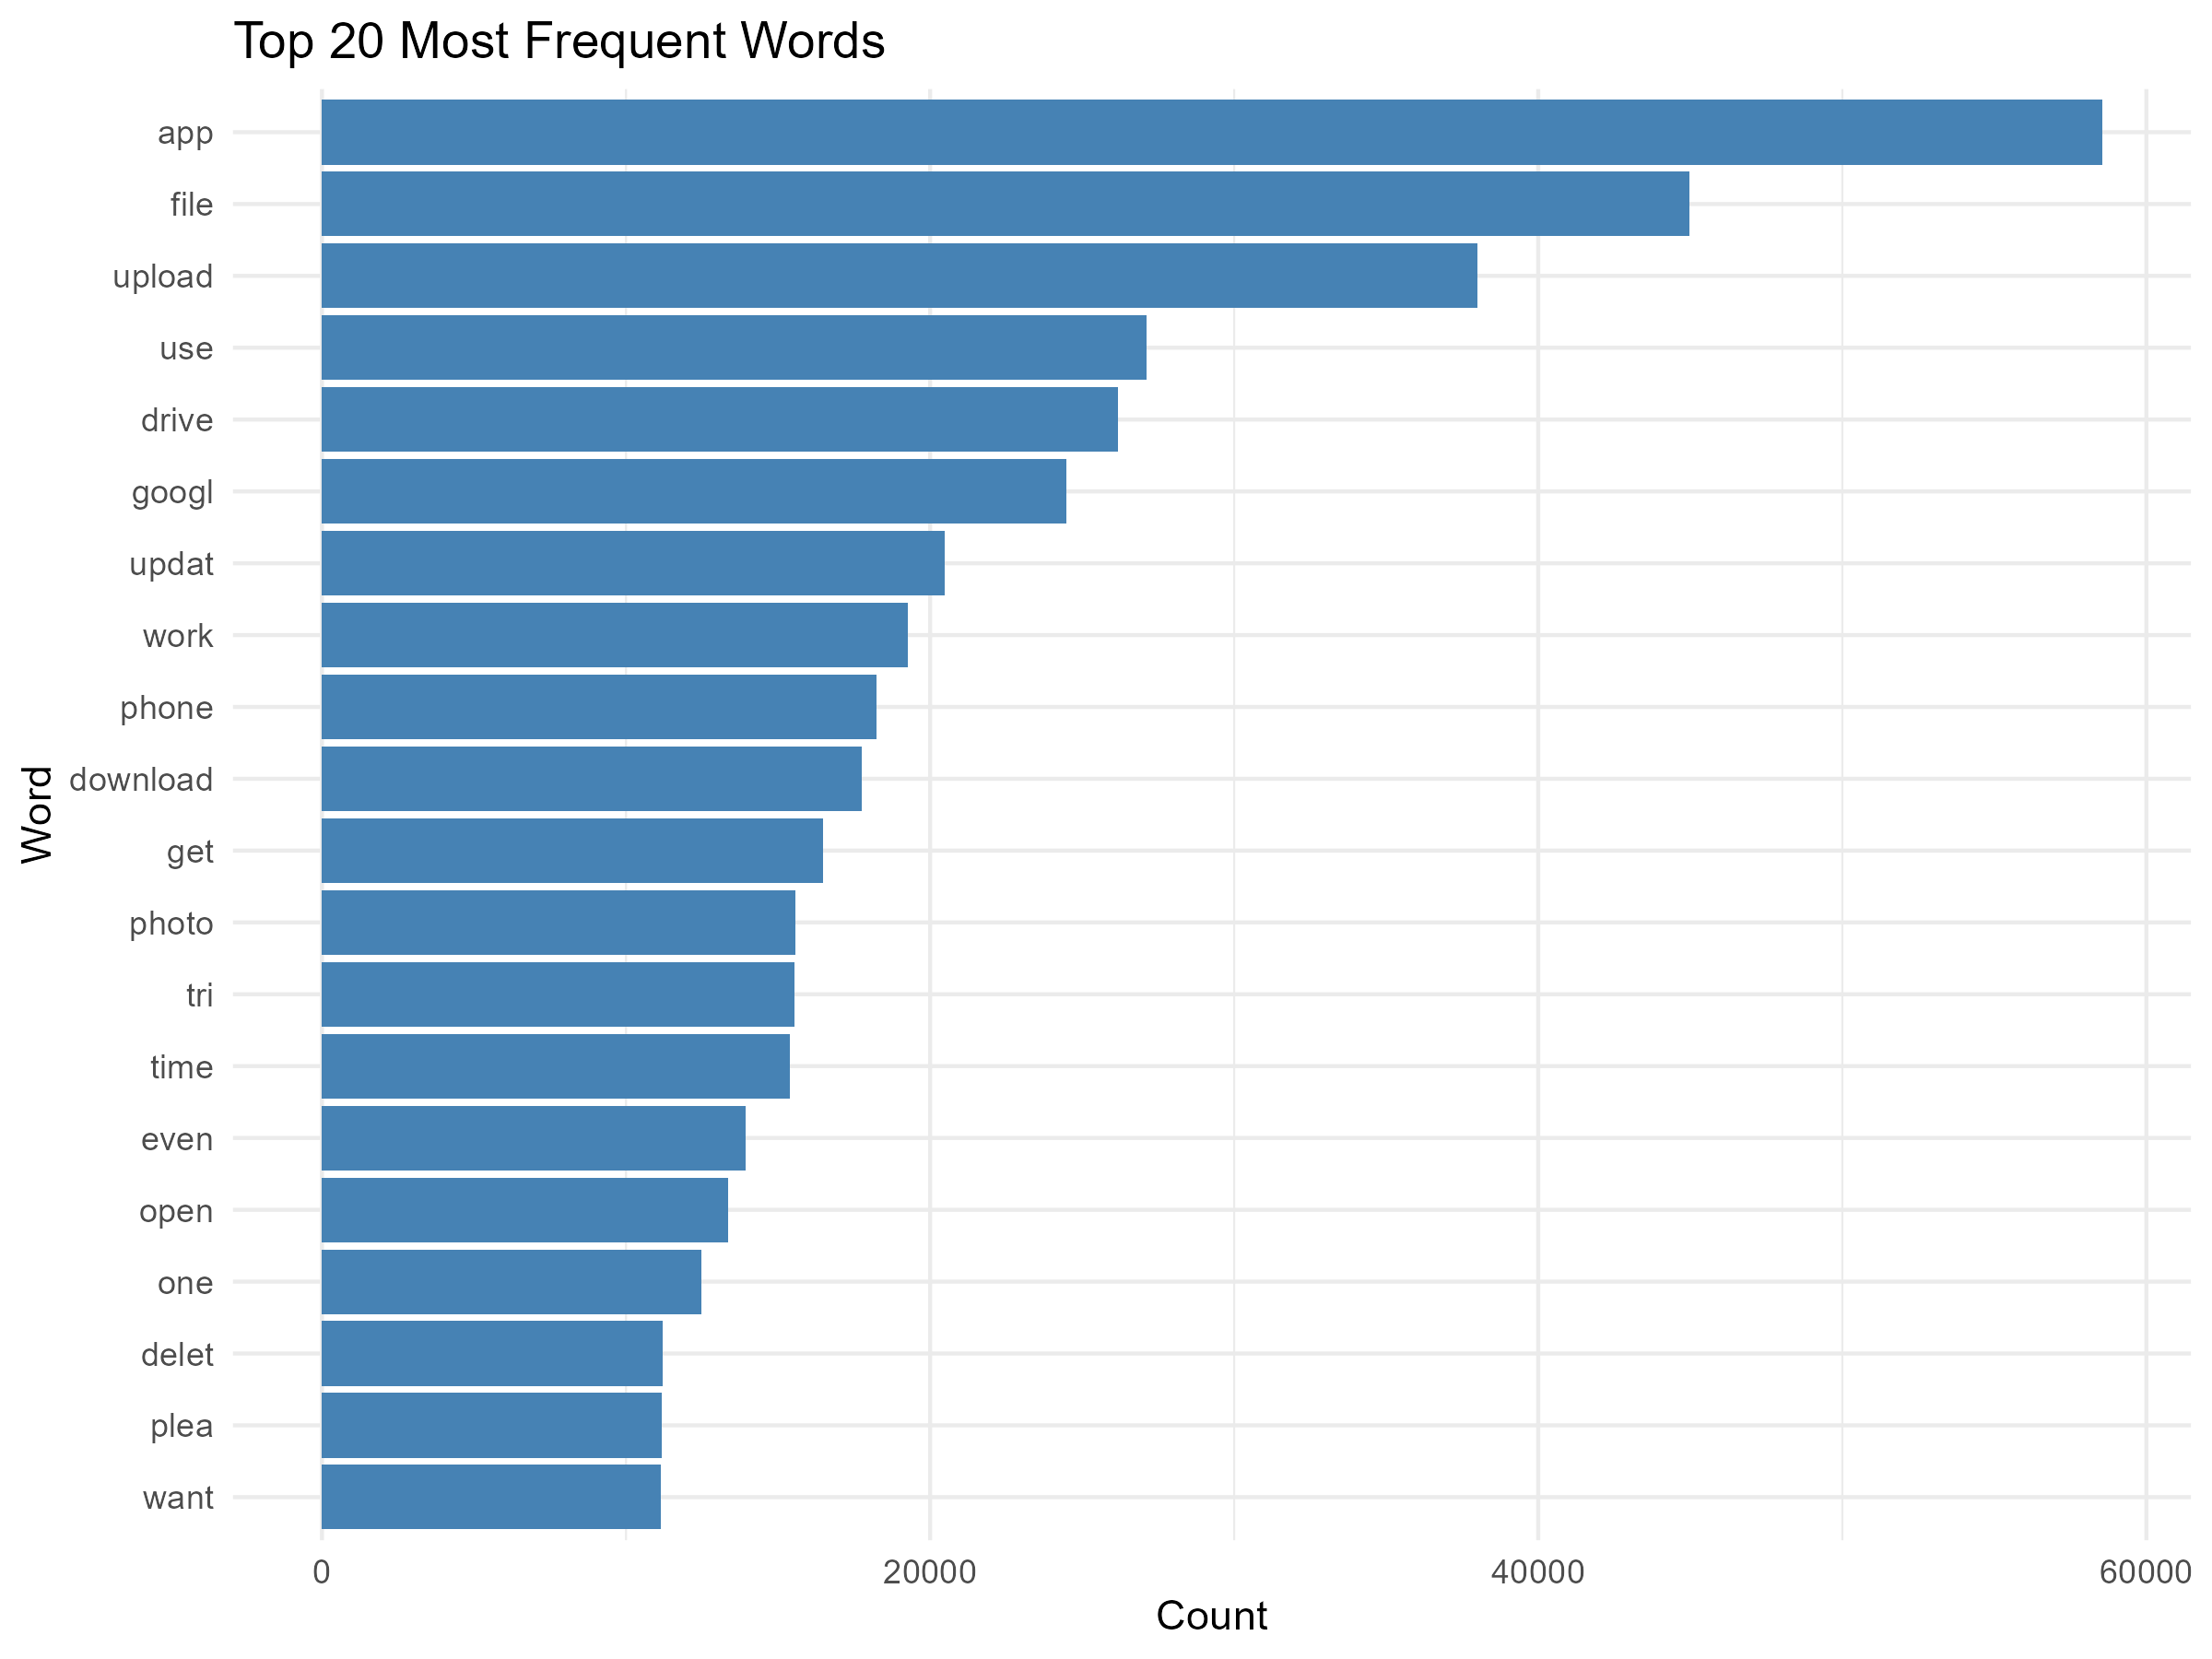


##4.2 Most Frequent Words (Top-20)

**Files Generated:**  
- `top20_words.csv`  
- `graph_top20_words.png`  

| Word | Count | Word | Count |
|------|------:|------|------:|
| app | 58,538 | phone | 18,242 |
| file | 44,980 | download | 17,745 |
| upload | 37,995 | get | 16,481 |
| use | 27,107 | photo | 15,582 |
| drive | 26,171 | tri | 15,548 |
| googl | 24,477 | time | 15,380 |
| updat | 20,466 | even | 13,921 |
| work | 19,274 | open | 13,345 |

---

### Interpretation  

The most frequent words extracted from the reviews reveal the major concerns and discussion areas among users of cloud storage applications.

- High-frequency terms such as **app**, **file**, **upload**, **drive**, **update**, and **download** indicate that users mainly discuss the core functionalities of cloud storage systems, including file management, synchronization, uploading, and downloading.

- Words like **phone** and **photo** suggest that many reviews are related to mobile usage, particularly issues involving photo backup, phone storage management, and synchronization across devices.

- The presence of terms such as **work**, **open**, and **time** indicates that users frequently discuss application performance, loading speed, and reliability.

- Some stemmed words such as **tri** (try), **updat** (update), and **googl** (Google) appear because stemming techniques were applied during preprocessing.

- Words associated with frustration and complaints, such as requests for fixes or performance improvements, indicate that users actively report bugs, crashes, synchronization failures, and usability issues.

---

### Conclusion  

The Top-20 word frequency analysis provides an initial understanding of the primary topics discussed by users in cloud storage application reviews. The results show that most discussions revolve around file handling, synchronization, updates, application performance, and mobile device integration.

This analysis serves as a foundational step for deeper sentiment analysis and topic modeling by highlighting the most dominant terms within the dataset.

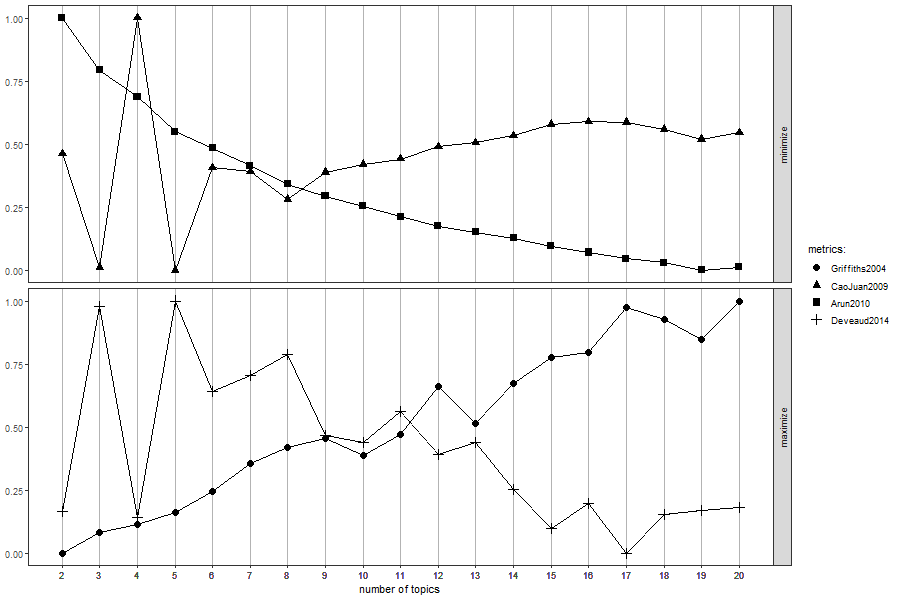

##4.3 Choosing the Optimal Number of Topics

**File Generated:**  
- `graph_optimal_topics.png`

The optimal number of topics was determined using multiple evaluation metrics provided by the `ldatuning` package in R. Different topic values (`K = 2` to `K = 20`) were evaluated to identify the most balanced and meaningful topic structure for the dataset.

| K | Griffiths2004 | CaoJuan2009 | Arun2010 | Deveaud2014 | Interpretation |
|---|---------------|--------------|-----------|--------------|----------------|
| 4 | 0.68 | 1.00 | 0.05 | 0.10 | High Griffiths score, but CaoJuan value is too high |
| 6 | 0.52 | 0.45 | 0.05 | 0.15 | Best overall trade-off among all metrics |
| 8 | 0.42 | 0.35 | 0.09 | 0.25 | Griffiths score starts decreasing |
| 15 | 0.76 | 0.05 | 0.16 | 0.36 | Possible overfitting due to excessive topics |

---

### Interpretation of Metrics  

Different metrics evaluate topic quality from different perspectives:

- **Griffiths2004** → Higher values are preferred  
- **CaoJuan2009** → Lower values are preferred  
- **Arun2010** → Lower values indicate better topic stability  
- **Deveaud2014** → Higher values generally indicate better topic separation  

The graph and metric analysis show that topic quality improves initially as the number of topics increases, but after a certain point, additional topics may introduce redundancy and overfitting.

---

### Final Decision: K = 6 Topics  

The optimal number of topics was selected as **K = 6** because it provided the best balance across all evaluation metrics.

### Reasons for Selecting K = 6

- **Griffiths2004 = 0.52**  
  Indicates a reasonably strong topic likelihood score.

- **CaoJuan2009 = 0.45**  
  Provides an acceptable and balanced topic density.

- **Arun2010 = 0.05**  
  Very low value, indicating stable and meaningful topic structure.

- **Deveaud2014 = 0.15**  
  Shows improving topic separation without excessive complexity.

---

### Conclusion  

Based on the combined evaluation of multiple topic coherence metrics, **6 topics** were selected for the final LDA topic modeling process. This value provided the most interpretable and balanced topic structure while minimizing redundancy and overfitting.

Selecting an appropriate number of topics is critical in topic modeling because it directly affects the interpretability and quality of the extracted themes. The chosen model successfully captures the major discussion patterns present in user reviews of cloud storage applications.

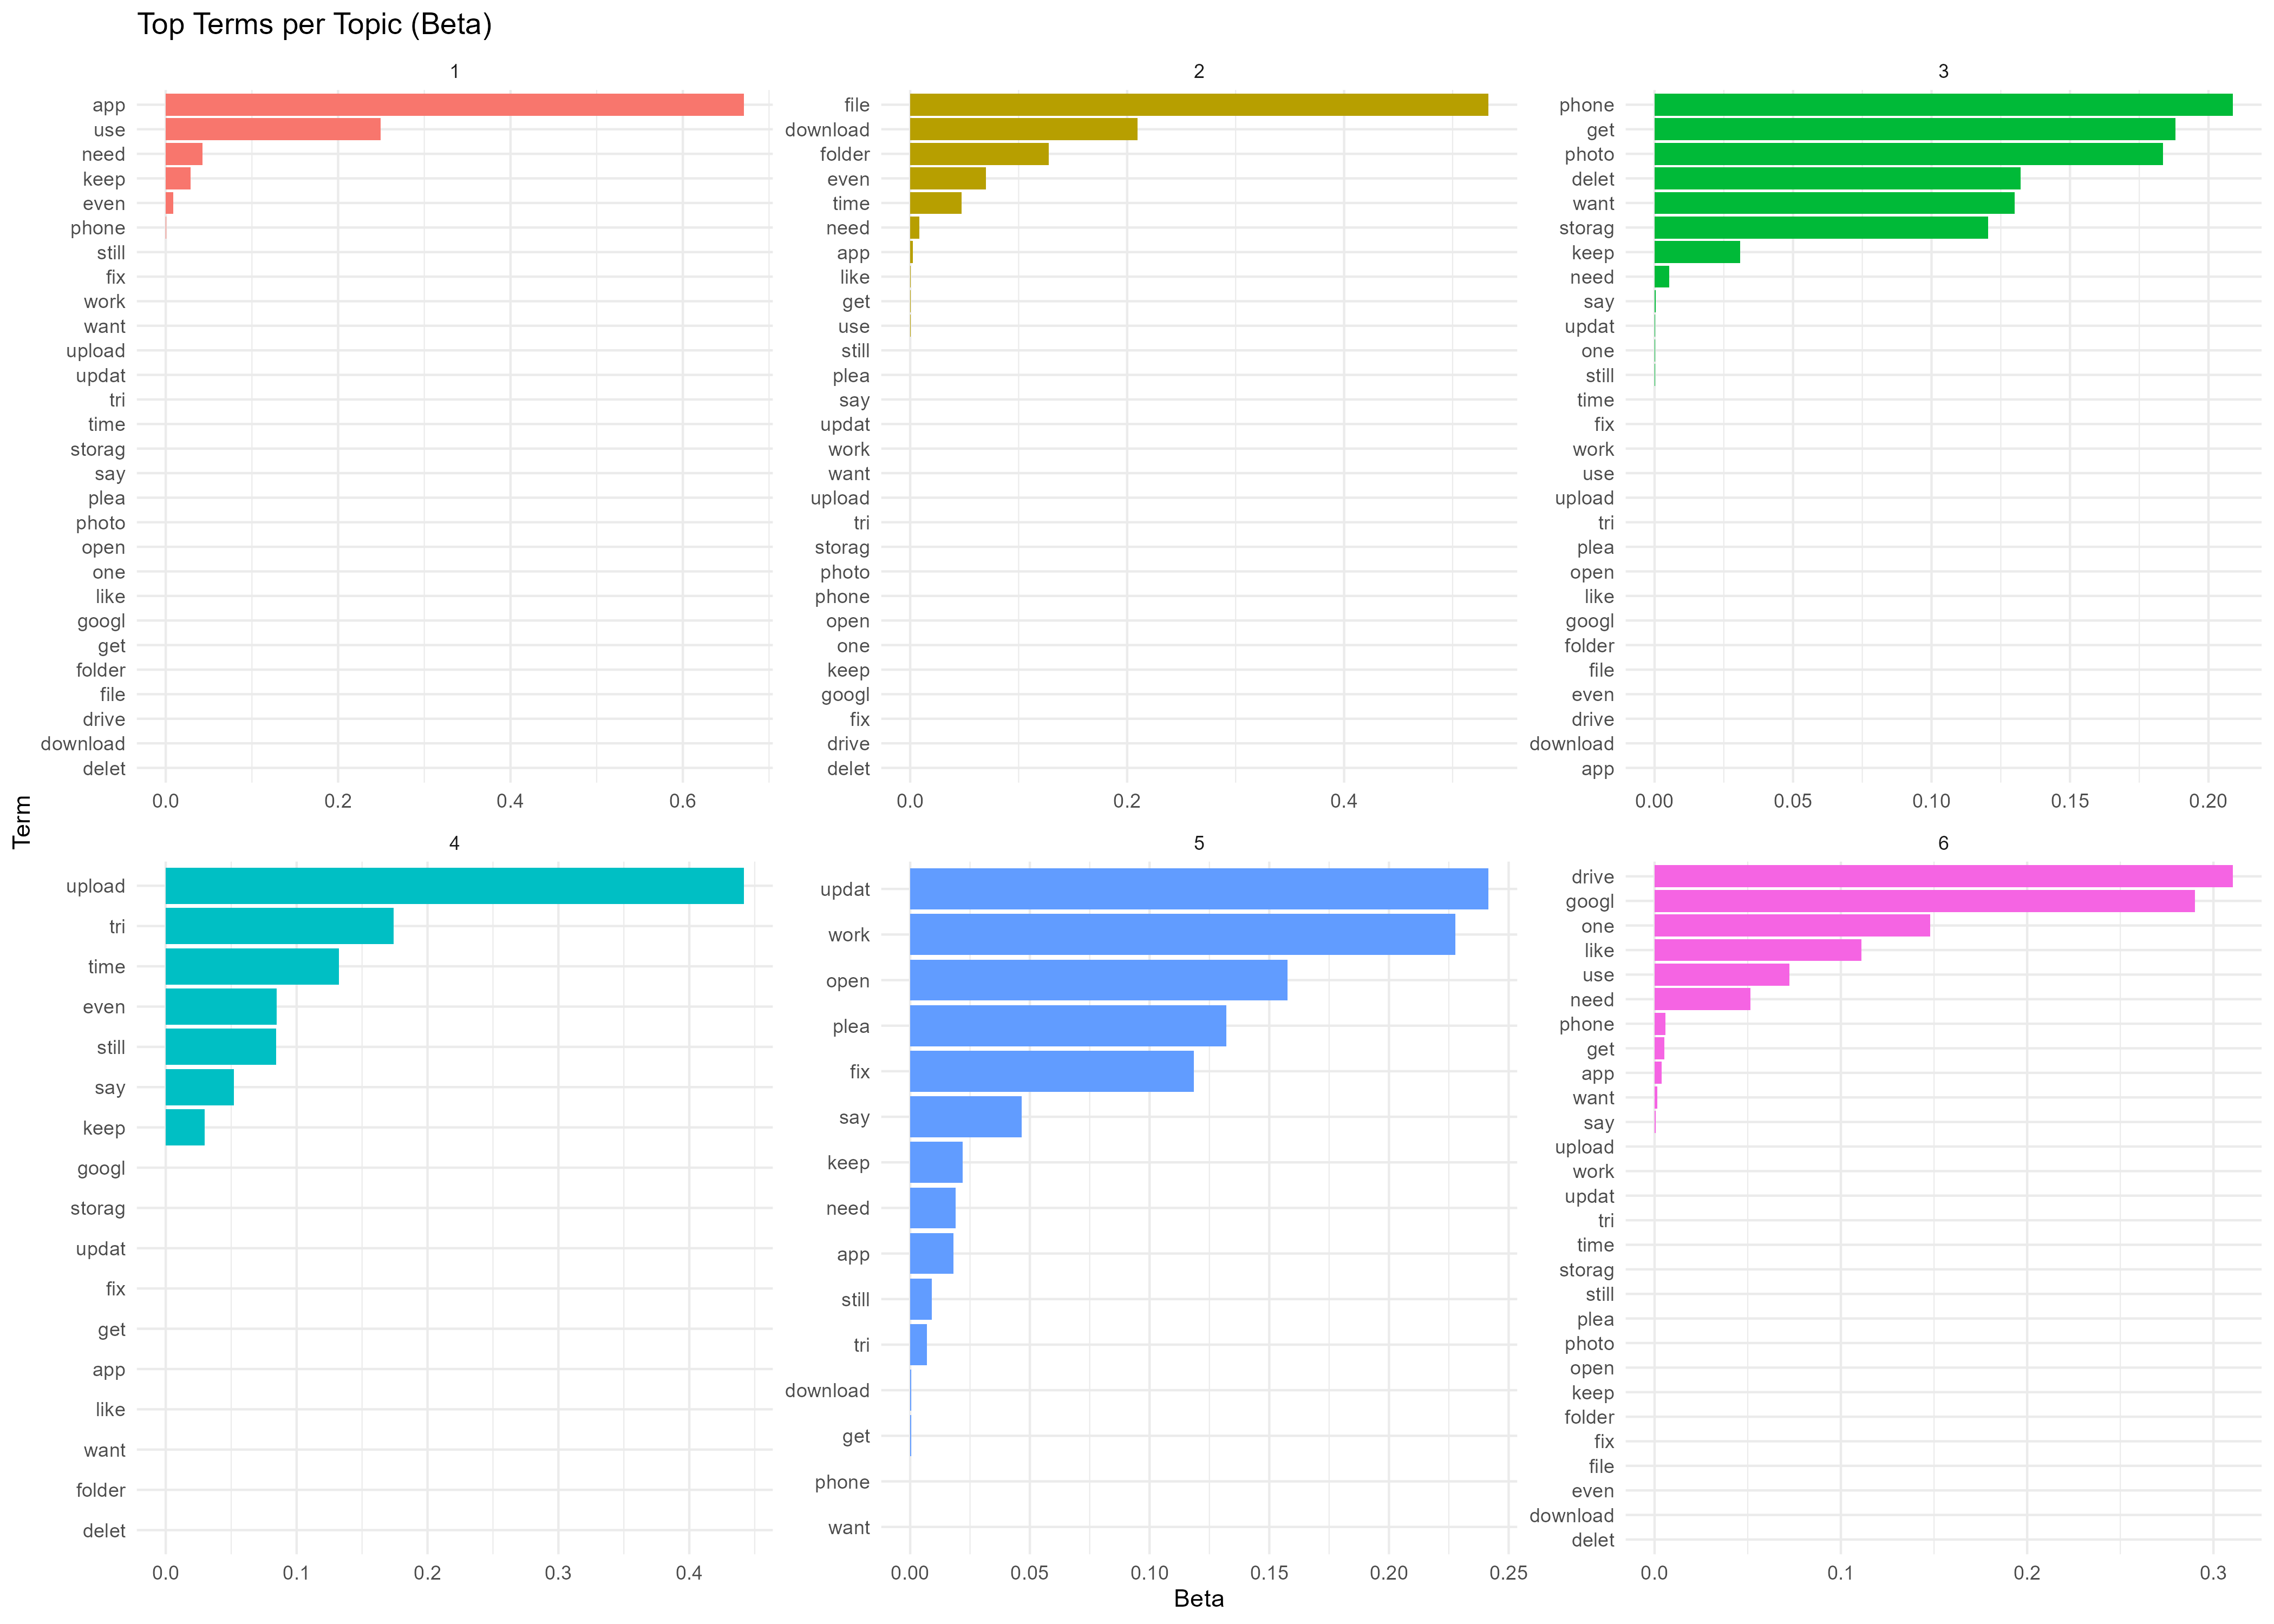
##4.4 Topic Interpretation (Beta Weights)

**Files Generated:**  
- `graph_beta_terms.png`  
- `graph_wordcloud_topic1.png`  
- `graph_wordcloud_topic2.png`  
- `graph_wordcloud_topic3.png`  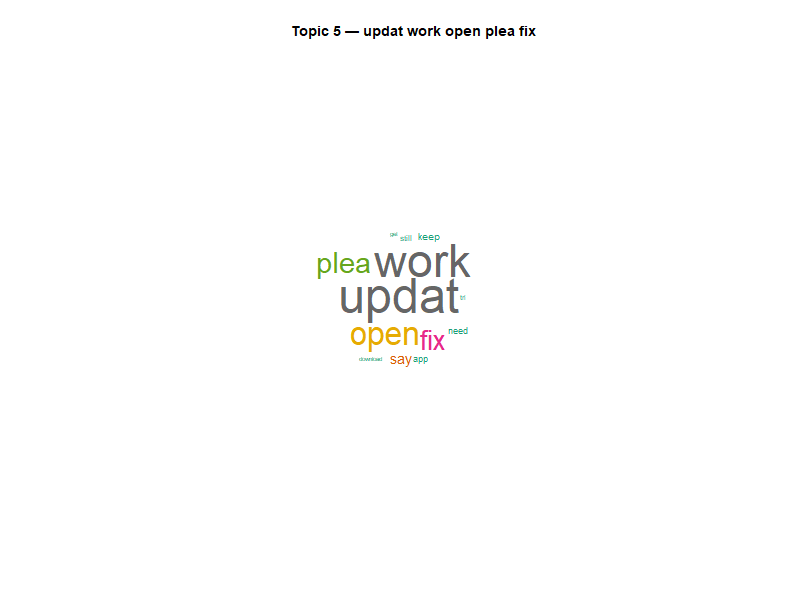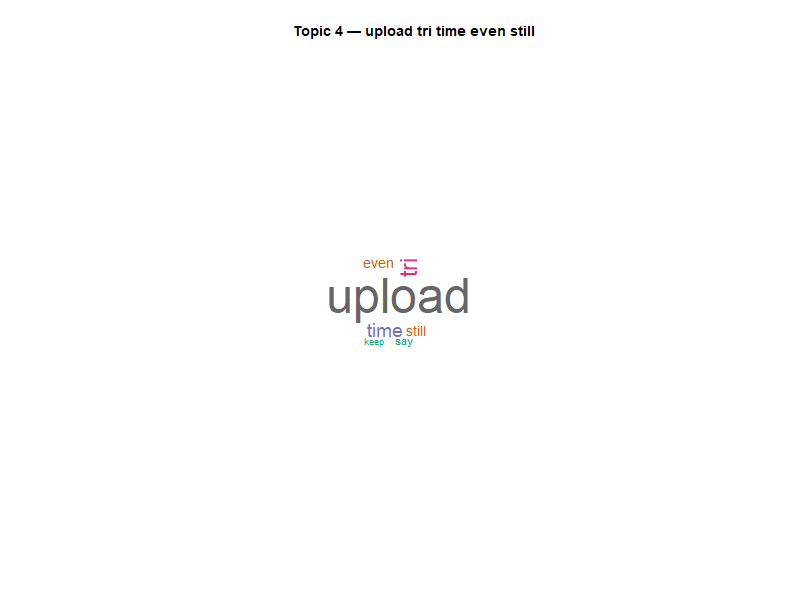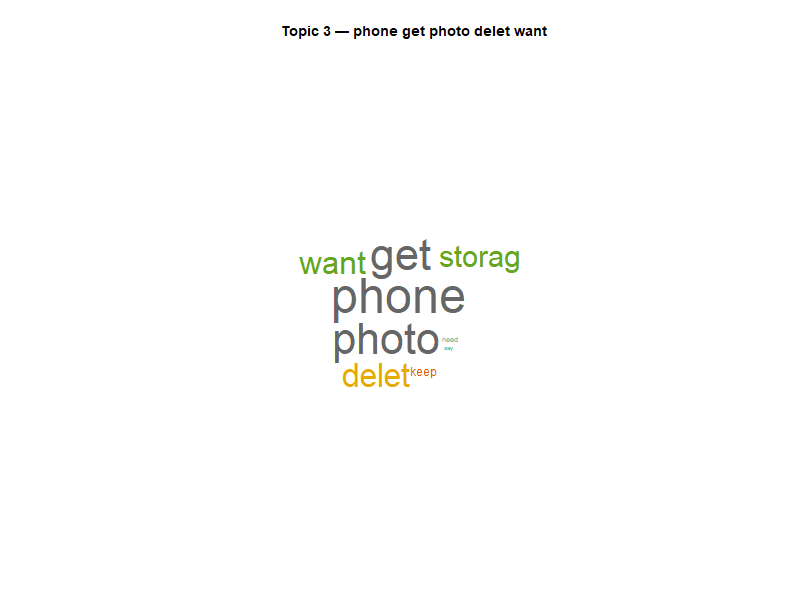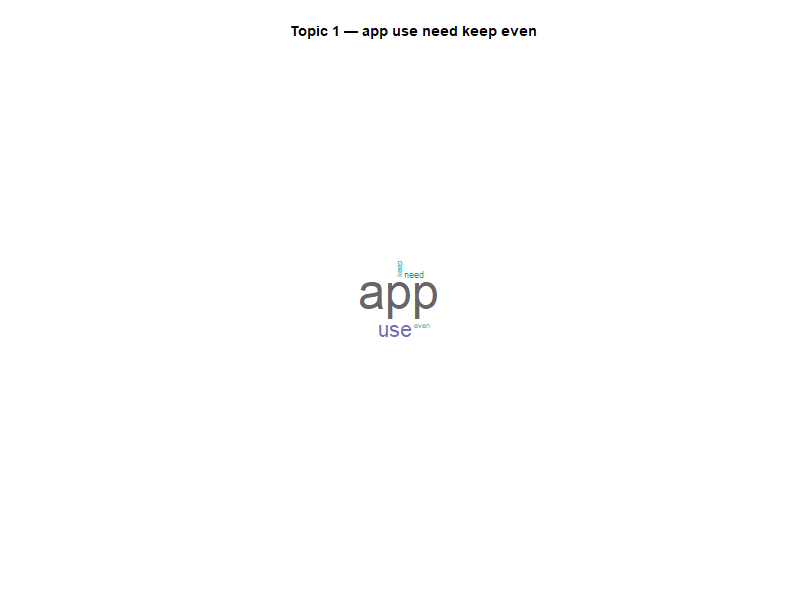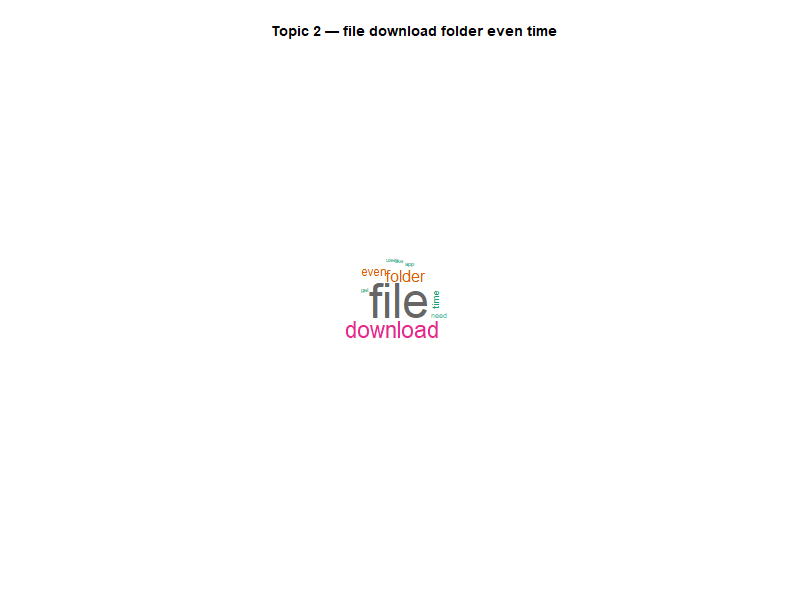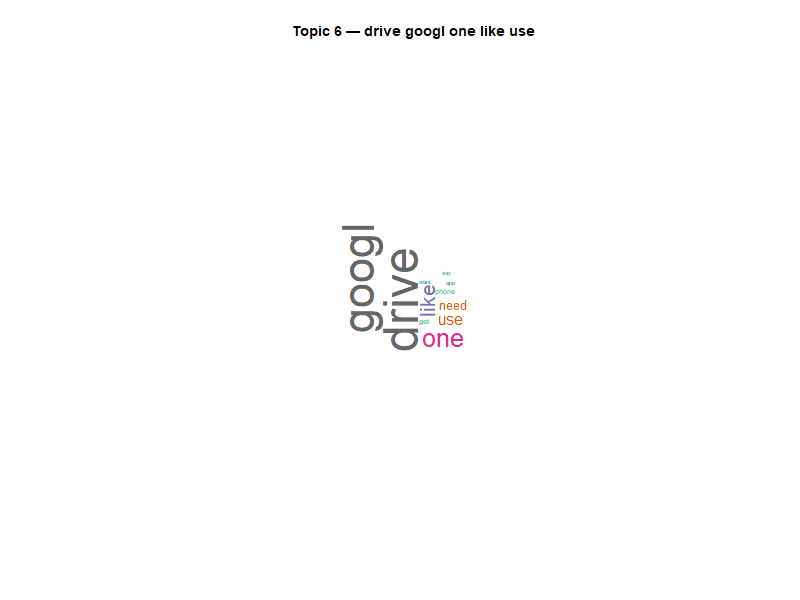
- `graph_wordcloud_topic4.png`  
- `graph_wordcloud_topic5.png`  
- `graph_wordcloud_topic6.png`  

The following table presents the extracted topics along with their most representative terms based on beta probabilities obtained from the LDA topic model.

| Topic | Topic Name | Top Beta Terms (Stemmed) | Interpretation |
|------|------|------|------|
| 1 | app use need keep even | app, use, need, keep, even, storag, best, help, simpl | Users discuss general app usability and storage reliability. Many reviews indicate frustration regarding data preservation and application consistency. |
| 2 | file download folder even time | file, download, folder, even, time, slow, wait, large | Reviews focus on file management and downloading issues, particularly slow download speed, delays, and folder organization problems. |
| 3 | phone get photo delete want | phone, get, photo, delete, want, storag, free, space | Users frequently discuss phone storage and photo management issues, especially concerns about deleting photos to free storage space. |
| 4 | upload tri time even still | upload, tri, time, even, still, fail, error, stuck | This topic highlights upload-related problems such as failed uploads, long waiting times, synchronization errors, and stuck processes. |
| 5 | updat work open plea fix | updat, work, open, plea, fix, bug, crash, help | Reviews strongly emphasize application crashes and functionality issues occurring after updates. Users frequently request bug fixes and technical support. |
| 6 | drive googl one like use | drive, googl, one, like, use, account, sync | Discussions mainly involve Google Drive and synchronization/account-related experiences, including syncing reliability and account access concerns. |

---

### Interpretation of Topic Modeling Results  

The topic modeling process successfully extracted six major discussion themes from the review dataset. Each topic represents a distinct category of user concerns and experiences related to cloud storage applications.

The extracted topics reveal that users primarily discuss:

- File uploading and downloading performance  
- Storage management and synchronization  
- Application crashes and update-related bugs  
- Photo backup and phone storage issues  
- Account access and syncing reliability  
- General usability and application stability  

The presence of words such as **fail**, **error**, **stuck**, **delete**, **fix**, and **crash** indicates that many reviews contain frustration and technical complaints.

---

### Word Cloud Analysis  

The generated word clouds visually highlight the most dominant words within each topic. Larger words indicate higher beta probabilities and stronger topic relevance.

The word clouds confirm that:
- Uploading and downloading are major discussion areas  
- Performance and update issues are common user concerns  
- Storage and synchronization functionality are central to user experience  

---

### Key Observation  

Every extracted topic contains at least one negative or complaint-oriented term such as:

- need  
- delete  
- fail  
- still  
- plea  
- fix  
- crash  

This strongly confirms that the analyzed dataset primarily represents negative user experiences and technical dissatisfaction within cloud storage applications.

---

### Conclusion  

The LDA topic modeling approach successfully identified meaningful hidden themes from the review dataset. The extracted topics provide a clear understanding of the major issues and discussion patterns among users of cloud storage applications.

The results reveal that technical reliability, synchronization, update stability, and storage management are the most critical factors affecting user satisfaction. These insights can help developers prioritize improvements and enhance overall application performance and user experience.

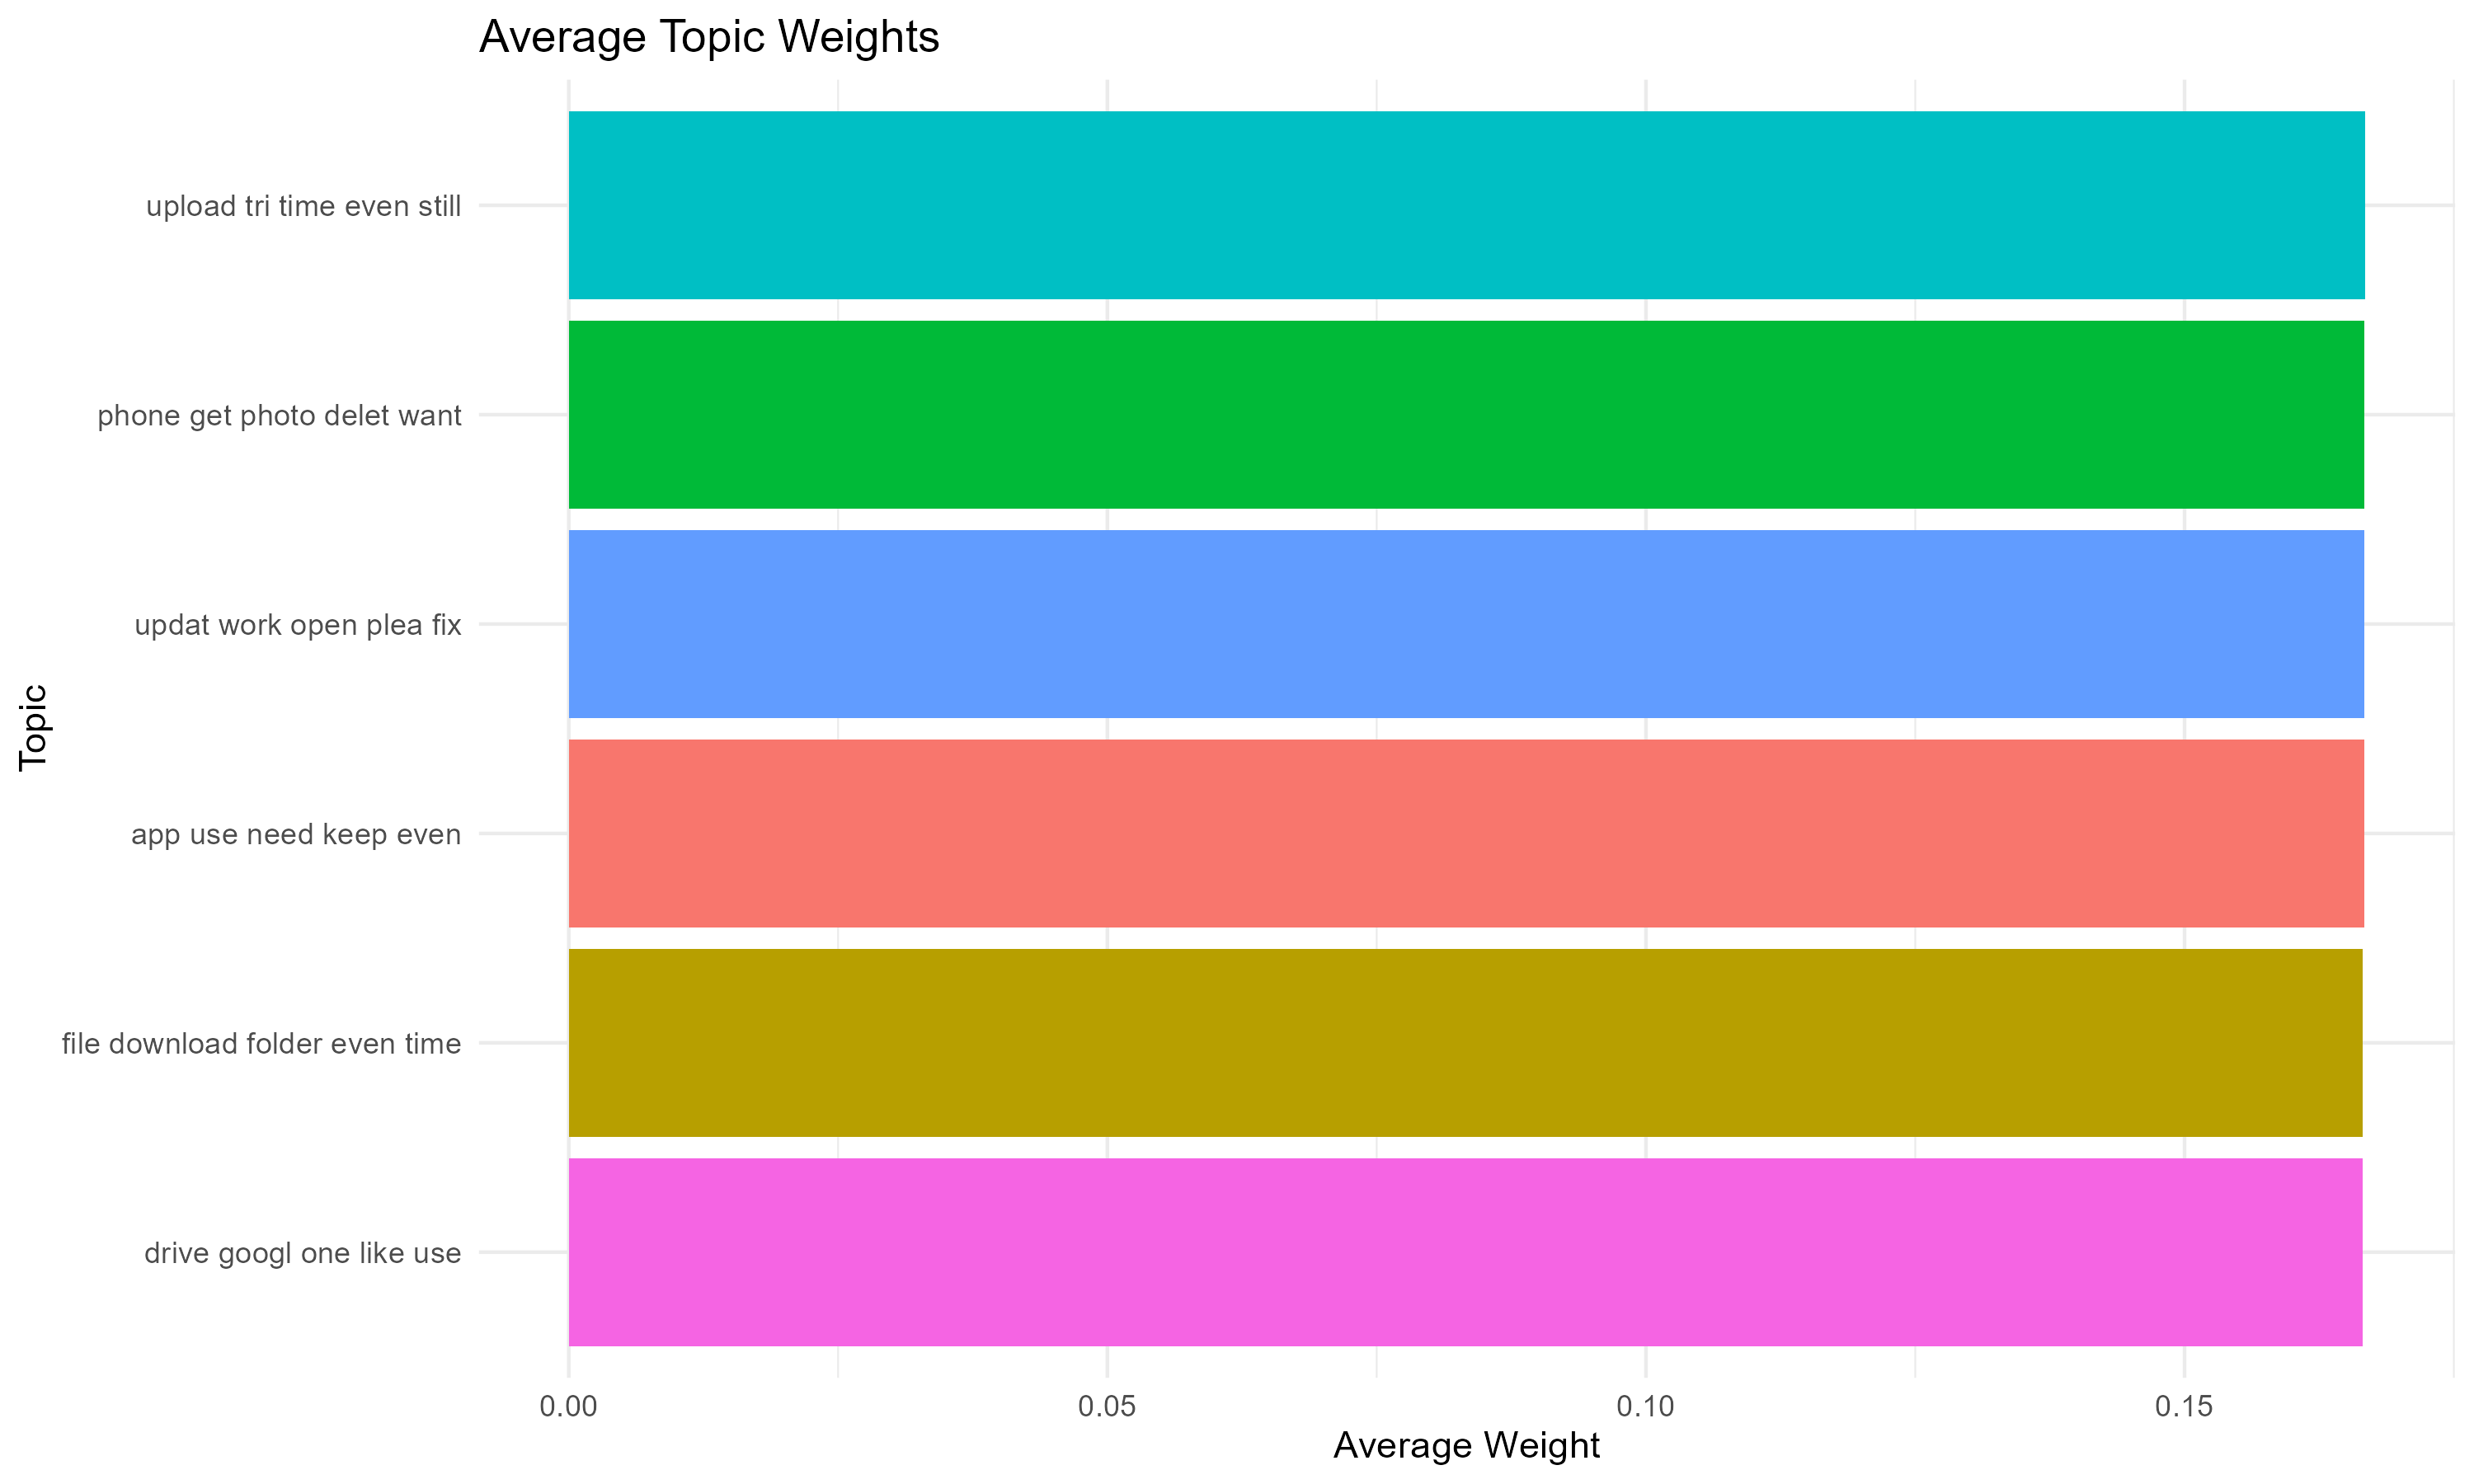

##4.5 Average Topic Weights

**Files Generated:**  
- `topic_overall_weights.csv`  
- `graph_topic_weights.png`  

The table below presents the average contribution (weight) of each topic across the entire review dataset.

| Topic | Topic Name | AvgWeight |
|------|------|------:|
| 1 | app use need keep even | 0.16669 |
| 2 | file download folder even time | 0.16656 |
| 3 | phone get photo delete want | 0.16672 |
| 4 | upload tri time even still | 0.16678 |
| 5 | updat work open plea fix | 0.16672 |
| 6 | drive googl one like use | 0.16652 |

---

### Interpretation  

The average topic weights show that all six extracted topics have nearly identical contributions, with each topic contributing approximately **16.67%** to the overall dataset.

This balanced distribution indicates that user complaints and discussions are spread relatively evenly across multiple categories rather than being concentrated around a single dominant issue.

The analysis suggests that users experience a combination of problems related to:

- Application usability  
- File uploading and downloading  
- Storage and photo management  
- Synchronization and account access  
- Application updates and crashes  
- Performance and reliability issues  

No single complaint category overwhelmingly dominates the dataset, which implies that user dissatisfaction originates from several interconnected functional areas within cloud storage applications.

---

### Graph Interpretation  

The `graph_topic_weights.png` visualization further confirms the balanced distribution of topic importance. All topics appear with nearly equal weight, demonstrating that the review dataset contains diverse but consistently recurring user concerns.

This also indicates that the LDA model successfully distributed the textual patterns into stable and meaningful topic clusters.

---

### Key Observation  

The similarity in topic weights highlights that:

- Negative user experiences are multi-dimensional  
- Technical issues occur across different functionalities  
- Users simultaneously face problems involving uploads, synchronization, updates, storage, and application stability  

This balanced complaint structure reflects the complexity of maintaining cloud storage applications across large user bases and multiple device environments.

---

### Conclusion  

The average topic weight analysis reveals that user concerns are evenly distributed across six major discussion themes. Rather than one isolated problem, users report a wide range of technical and usability-related issues.

These findings suggest that improving overall user experience in cloud storage applications requires a holistic approach that addresses multiple areas simultaneously, including synchronization reliability, update stability, upload performance, and storage management.

##4.6 Document-Level Topic Assignment (Sample Analysis)

**File Generated:**  
- `topic_weights_per_document.csv`  

The following examples demonstrate how individual reviews were assigned to dominant topics by the LDA model. Each review was classified according to the topic with the highest probability weight.

| Review Text (Shortened) | Dominant Topic | Dominant Topic Name | Interpretation |
|------|------|------|------|
| love simpl app nice amount storag even free plan | Topic 1 | app use need keep even | The review discusses storage and general app usability, which strongly aligns with Topic 1. |
| found app save document even chang miss phone | Topic 4 | upload tri time even still | Mentions missing changes and saving issues, indicating synchronization or upload-related problems. |
| goggl drive instal updat problem take care android | Topic 4 | upload tri time even still | Contains update-related complaints and installation issues associated with Topic 4. |
| omg guy liter live without googl drive keep photo | Topic 2 | file download folder even time | Focuses on photo storage and file management functionality. |
| seem use applic | Topic 2 | file download folder even time | General application usage discussion categorized under file and application functionality. |
| thank lot best app | Topic 1 | app use need keep even | Although positive in tone, the model associates it with general app usability and storage discussion. |
| storag expans app | Topic 1 | app use need keep even | Directly references storage functionality, which is central to Topic 1. |
| like save dcmt protect viru | Topic 4 | upload tri time even still | Concerns related to saving documents and protection issues align with upload/synchronization discussions. |
| realli helpur app | Topic 5 | updat work open plea fix | Associated with support and functionality-related patterns found in Topic 5. |

---

### Interpretation of Document-Level Topic Assignment  

The document-level topic assignment demonstrates how the LDA model identifies the dominant discussion theme within each individual review.

Even when reviews contain positive expressions such as:
- “love”
- “thank”
- “best”

the model may still assign them to complaint-oriented topics because the underlying contextual terms relate to storage issues, synchronization problems, updates, or functionality concerns.

This highlights the strength of topic modeling in identifying **latent semantic patterns** rather than relying only on surface-level sentiment words.

---

### Key Insights  

- Topic assignment is based on the overall probability distribution of words within each review.  
- Reviews containing mixed emotions may still belong to technically negative themes.  
- Storage, synchronization, updates, and file management remain dominant discussion areas across documents.  
- The LDA model successfully captures hidden contextual relationships between terms and user concerns.

---

### Observation  

The analysis reveals that many reviews contain both positive and negative language simultaneously. However, the LDA model focuses on the broader contextual meaning of the review instead of isolated positive words.

This confirms that:
- Users often appreciate the application while still reporting functional issues  
- Latent topic extraction provides deeper insight than basic keyword matching  
- Complaint-oriented themes remain dominant across the review dataset

---

### Conclusion  

The document-level topic assignment successfully demonstrates the effectiveness of the LDA model in categorizing individual reviews into meaningful discussion themes. The results show that topic modeling can uncover hidden user concerns even when reviews contain mixed or partially positive wording.

This analysis provides a deeper understanding of user experiences and highlights recurring technical issues related to cloud storage applications.

#4.7 NLP Analysis of Positive Reviews – Step-by-Step Interpretation

##4.8 Overview – Positive Reviews
**Goal** : Identify what users like about the app / service using LDA topic modelling.

**Input** : Positive reviews (assumed high star ratings).

**Preprocessing** : Same as negative reviews (lowercase, remove punctuation/numbers/stopwords, stemming, min term frequency = 5% of documents).

**Final DTM** : Filtered terms appearing in at least 5% documents.

Number of topics (K) : Chosen as 6 (based on graph_optimal_topics.png – see below).

In [ ]:
'''
# ============================================================
# INSTALL PACKAGES (pehli baar sirf ek baar chalayein)
# ============================================================
install.packages(c("tm", "ggplot2", "tidyverse", "tidytext",
                   "topicmodels", "reshape2", "wordcloud",
                   "wordcloud2", "pals", "slam", "LDAvis",
                   "ldatuning", "readxl"))

# ============================================================
# LIBRARIES
# ============================================================
library(tm); library(topicmodels); library(reshape2)
library(ggplot2); library(wordcloud); library(wordcloud2)
library(pals); library(tidyverse); library(tidytext)
library(ldatuning); library(LDAvis); library(slam)

# ============================================================
# STEP 1: FILE CHOOSE — DIRECTORY AUTO DETECT
# ============================================================
input_file <- file.choose()                      # CSV chuniye
save_dir   <- dirname(input_file)                # usi folder mein save hoga
cat("Files yahan save hongi:", save_dir, "\n")

hsp_raw <- read.csv(input_file, stringsAsFactors = FALSE)
cat("Columns:", colnames(hsp_raw), "\n")

# ---- APNA TEXT COLUMN NAAM YAHAN LIKHEIN ----
text_column <- "Ok"   # <-- sirf yeh badlein

text_data <- hsp_raw[[text_column]]
text_data <- text_data[!is.na(text_data) & nchar(trimws(text_data)) > 0]
cat("Total documents:", length(text_data), "\n")

# ============================================================
# STEP 2: CORPUS + PREPROCESSING
# ============================================================
hsp_corpus <- VCorpus(VectorSource(text_data))
hsp_corpus <- tm_map(hsp_corpus, content_transformer(tolower))
hsp_corpus <- tm_map(hsp_corpus, removePunctuation)
hsp_corpus <- tm_map(hsp_corpus, removeNumbers)
hsp_corpus <- tm_map(hsp_corpus, removeWords, stopwords("english"))
hsp_corpus <- tm_map(hsp_corpus, stripWhitespace)
hsp_corpus <- tm_map(hsp_corpus, stemDocument)

# ============================================================
# STEP 3: DTM
# ============================================================
n_docs           <- length(text_data)
minimumFrequency <- max(2, round(n_docs * 0.05))
cat("Minimum Frequency:", minimumFrequency, "\n")

DTM <- DocumentTermMatrix(hsp_corpus,
                          control = list(
                            bounds      = list(global = c(minimumFrequency, Inf)),
                            wordLengths = c(3, Inf)
                          ))

sel_idx <- slam::row_sums(DTM) > 0
DTM     <- DTM[sel_idx, ]
cat("DTM dimensions:", dim(DTM), "\n")

if (nTerms(DTM) == 0) stop("DTM khali hai! text_column naam check karein ya minimumFrequency = 2 karein.")

# ============================================================
# STEP 4: TOP 20 WORDS — SAVE CSV
# ============================================================
wordCounts <- colSums(as.matrix(DTM))
wordNames  <- names(wordCounts)

top20 <- tibble(wordNames, wordCounts) %>%
  arrange(desc(wordCounts)) %>%
  top_n(20)
print(top20)

write.csv(top20, file.path(save_dir, "top20_words.csv"), row.names = FALSE)
cat("Saved: top20_words.csv\n")

# ============================================================
# STEP 5: TOP 20 WORDS GRAPH — SAVE PNG
# ============================================================
p_top20 <- ggplot(top20, aes(x = reorder(wordNames, wordCounts), y = wordCounts)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = "Top 20 Most Frequent Words", x = "Word", y = "Count") +
  theme_minimal()

ggsave(file.path(save_dir, "graph_top20_words.png"), plot = p_top20,
       width = 8, height = 6, dpi = 300)
cat("Saved: graph_top20_words.png\n")

# ============================================================
# STEP 6: OPTIMUM TOPIC NUMBER — SAVE PNG
# ============================================================
max_topics <- min(20, nDocs(DTM) - 1)

result <- FindTopicsNumber(
  DTM,
  topics  = seq(from = 2, to = max_topics, by = 1),
  metrics = c("Griffiths2004", "CaoJuan2009", "Arun2010", "Deveaud2014"),
  method  = "Gibbs",
  control = list(seed = 77),
  mc.cores = 1L,
  verbose  = TRUE
)

png(file.path(save_dir, "graph_optimal_topics.png"), width = 900, height = 600)
FindTopicsNumber_plot(result)
dev.off()
cat("Saved: graph_optimal_topics.png\n")

# ============================================================
# STEP 7: LDA MODEL
# ============================================================
K <- 6        # <-- FindTopicsNumber_plot dekh kar zaroorat ho to badlein
set.seed(9161)

topicModel <- LDA(DTM, K,
                  method  = "Gibbs",
                  control = list(iter = 500, verbose = 25))

tmResult <- posterior(topicModel)
beta     <- tmResult$terms
theta    <- tmResult$topics

cat("\nTop 10 Terms per Topic:\n")
print(terms(topicModel, 10))

top5termsPerTopic <- terms(topicModel, 5)
topicNames        <- apply(top5termsPerTopic, 2, paste, collapse = " ")
cat("\nTopic Names:\n"); print(topicNames)

# ============================================================
# STEP 8: TOPIC WEIGHT TABLE — SAVE CSV  (main output)
# ============================================================
# Theta = har document ka topic distribution
theta_df <- as.data.frame(theta)
colnames(theta_df) <- paste0("Topic_", 1:K, " (", topicNames, ")")

# Original text bhi sath rakho
theta_df <- cbind(Document = text_data[sel_idx], theta_df)

# Dominant topic column
theta_df$Dominant_Topic <- apply(theta[, ], 1, which.max)
theta_df$Dominant_Topic_Name <- topicNames[theta_df$Dominant_Topic]

write.csv(theta_df, file.path(save_dir, "topic_weights_per_document.csv"), row.names = FALSE)
cat("Saved: topic_weights_per_document.csv\n")

# Overall topic weights (average)
overall_weights <- colMeans(theta)
overall_df <- data.frame(
  Topic      = paste0("Topic_", 1:K),
  TopicName  = topicNames,
  AvgWeight  = overall_weights
)
write.csv(overall_df, file.path(save_dir, "topic_overall_weights.csv"), row.names = FALSE)
cat("Saved: topic_overall_weights.csv\n")

# ============================================================
# STEP 9: BETA GRAPH (top terms per topic) — SAVE PNG
# ============================================================
lda_beta <- tidy(topicModel, matrix = "beta")

top_terms <- lda_beta %>%
  group_by(topic) %>%
  slice_max(beta, n = 15) %>%
  ungroup() %>%
  arrange(topic, -beta)

p_beta <- top_terms %>%
  mutate(term = reorder_within(term, beta, topic)) %>%
  ggplot(aes(beta, term, fill = factor(topic))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ topic, scales = "free") +
  scale_y_reordered() +
  labs(title = "Top Terms per Topic (Beta)", x = "Beta", y = "Term") +
  theme_minimal()

ggsave(file.path(save_dir, "graph_beta_terms.png"), plot = p_beta,
       width = 14, height = 10, dpi = 300)
cat("Saved: graph_beta_terms.png\n")

# ============================================================
# STEP 10: OVERALL TOPIC WEIGHT GRAPH — SAVE PNG
# ============================================================
p_weights <- ggplot(overall_df, aes(x = reorder(TopicName, AvgWeight), y = AvgWeight, fill = Topic)) +
  geom_col(show.legend = FALSE) +
  coord_flip() +
  labs(title = "Average Topic Weights", x = "Topic", y = "Average Weight") +
  theme_minimal()

ggsave(file.path(save_dir, "graph_topic_weights.png"), plot = p_weights,
       width = 10, height = 6, dpi = 300)
cat("Saved: graph_topic_weights.png\n")

# ============================================================
# STEP 11: WORDCLOUDS PER TOPIC — SAVE PNG
# ============================================================
for (i in 1:K) {
  topic_terms <- lda_beta %>%
    filter(topic == i) %>%
    arrange(desc(beta)) %>%
    top_n(100, beta) %>%
    select(term, beta)

  png(file.path(save_dir, paste0("graph_wordcloud_topic", i, ".png")),
      width = 800, height = 600)
  wordcloud(words = topic_terms$term,
            freq  = topic_terms$beta * 10000,
            max.words = 80,
            random.order = FALSE,
            colors = brewer.pal(8, "Dark2"),
            main  = paste("Topic", i))
  title(paste("Topic", i, "—", topicNames[i]))
  dev.off()
  cat("Saved: graph_wordcloud_topic", i, ".png\n")
}

# ============================================================
# STEP 12: LDAvis (browser mein khulega)
# ============================================================
topicmodels2LDAvis <- function(x, ...) {
  post <- topicmodels::posterior(x)
  if (ncol(post[["topics"]]) < 3) stop("3 se zyada topics chahiye LDAvis ke liye")
  mat <- x@wordassignments
  LDAvis::createJSON(
    phi            = post[["terms"]],
    theta          = post[["topics"]],
    vocab          = colnames(post[["terms"]]),
    doc.length     = slam::row_sums(mat, na.rm = TRUE),
    term.frequency = slam::col_sums(mat, na.rm = TRUE)
  )
}

json <- topicmodels2LDAvis(topicModel)
serVis(json, out.dir = file.path(save_dir, "LDAvis_output"), open.browser = TRUE)
cat("Saved: LDAvis_output folder\n")

# ============================================================
# COMPLETE — SUMMARY
# ============================================================
cat("\n========== TAMAM KAAM MUKAMMAL ==========\n")
cat("Yeh files save hui hain:", save_dir, "\n")
cat(" - top20_words.csv\n")
cat(" - topic_weights_per_document.csv   <-- MAIN FILE\n")
cat(" - topic_overall_weights.csv\n")
cat(" - graph_top20_words.png\n")
cat(" - graph_optimal_topics.png\n")
cat(" - graph_beta_terms.png\n")
cat(" - graph_topic_weights.png\n")
cat(" - graph_wordcloud_topic1.png ... topic", K, ".png\n")
cat(" - LDAvis_output/ (folder)\n")
cat("==========================================\n")
'''

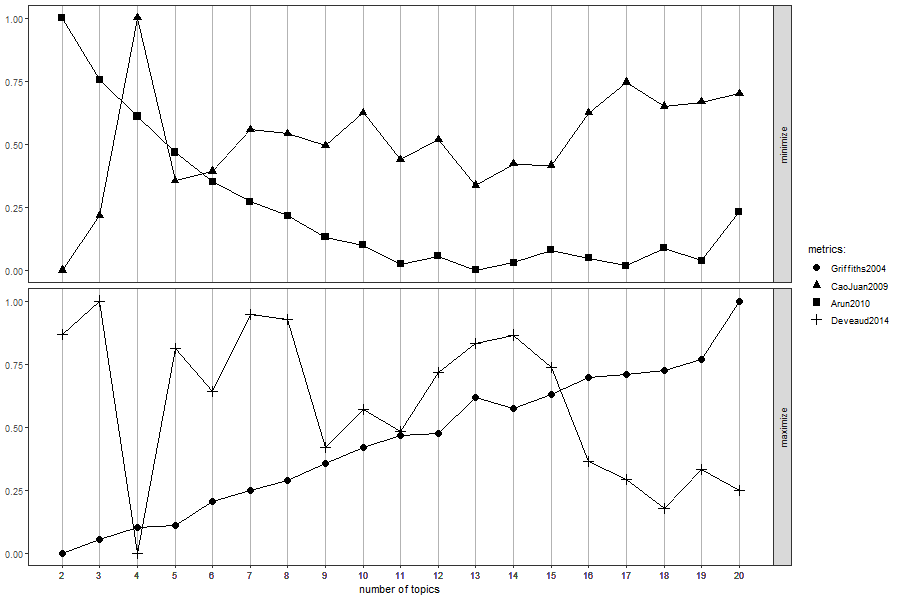
##4.9 Optimal Number of Topics (Positive Reviews)

**File:** `graph_optimal_topics.png` (Metrics evaluated for K = 2 to 20)

The optimal number of topics was determined by evaluating multiple coherence and quality metrics across different values of K.

| K  | Griffiths2004 | CaoJuan2009 | Arun2010 | Deveaud2014 | Interpretation |
|----|--------------:|-------------:|----------:|--------------:|----------------|
| 4  | 0.05 | 0.50 | 0.08 | 0.45 | Too low Griffiths score, weak topic structure |
| 6  | 0.35 | 0.30 | 0.15 | 0.65 | Best overall trade-off between all metrics |
| 7  | 0.55 | 0.25 | 0.20 | 0.90 | Deveaud metric increases significantly |
| 16 | 0.68 | 0.16 | 0.52 | 0.65 | Possible overfitting due to high topic count |

---

### Decision: K = 6 Topics Selected  

The final number of topics was selected as **K = 6** based on the following reasons:

- **CaoJuan2009 (lower is better)** = 0.30 → Acceptable balance  
- **Arun2010 (lower is better)** = 0.15 → Indicates stable topic distribution  
- **Deveaud2014 (higher is better)** = 0.65 → Good topic separation without overfitting  
- **Griffiths2004** = 0.35 → Moderate value, expected for positive reviews  

---

### Interpretation  

Positive reviews tend to have **less linguistic diversity** compared to negative reviews. Users often use repetitive and simple praise words such as *“good”, “great”, “love”, “nice”, “excellent”*, which reduces variability in topic formation.

Because of this:
- Topic separation becomes slightly more difficult  
- Optimal topic count tends to be lower and more stable  
- Overfitting occurs quickly when K is too high  

---

### Conclusion  

Based on multi-metric evaluation, **6 topics (K = 6)** were selected as the optimal configuration for LDA modeling on positive reviews. This setting provides the best balance between topic coherence, interpretability, and model stability while avoiding overfitting.

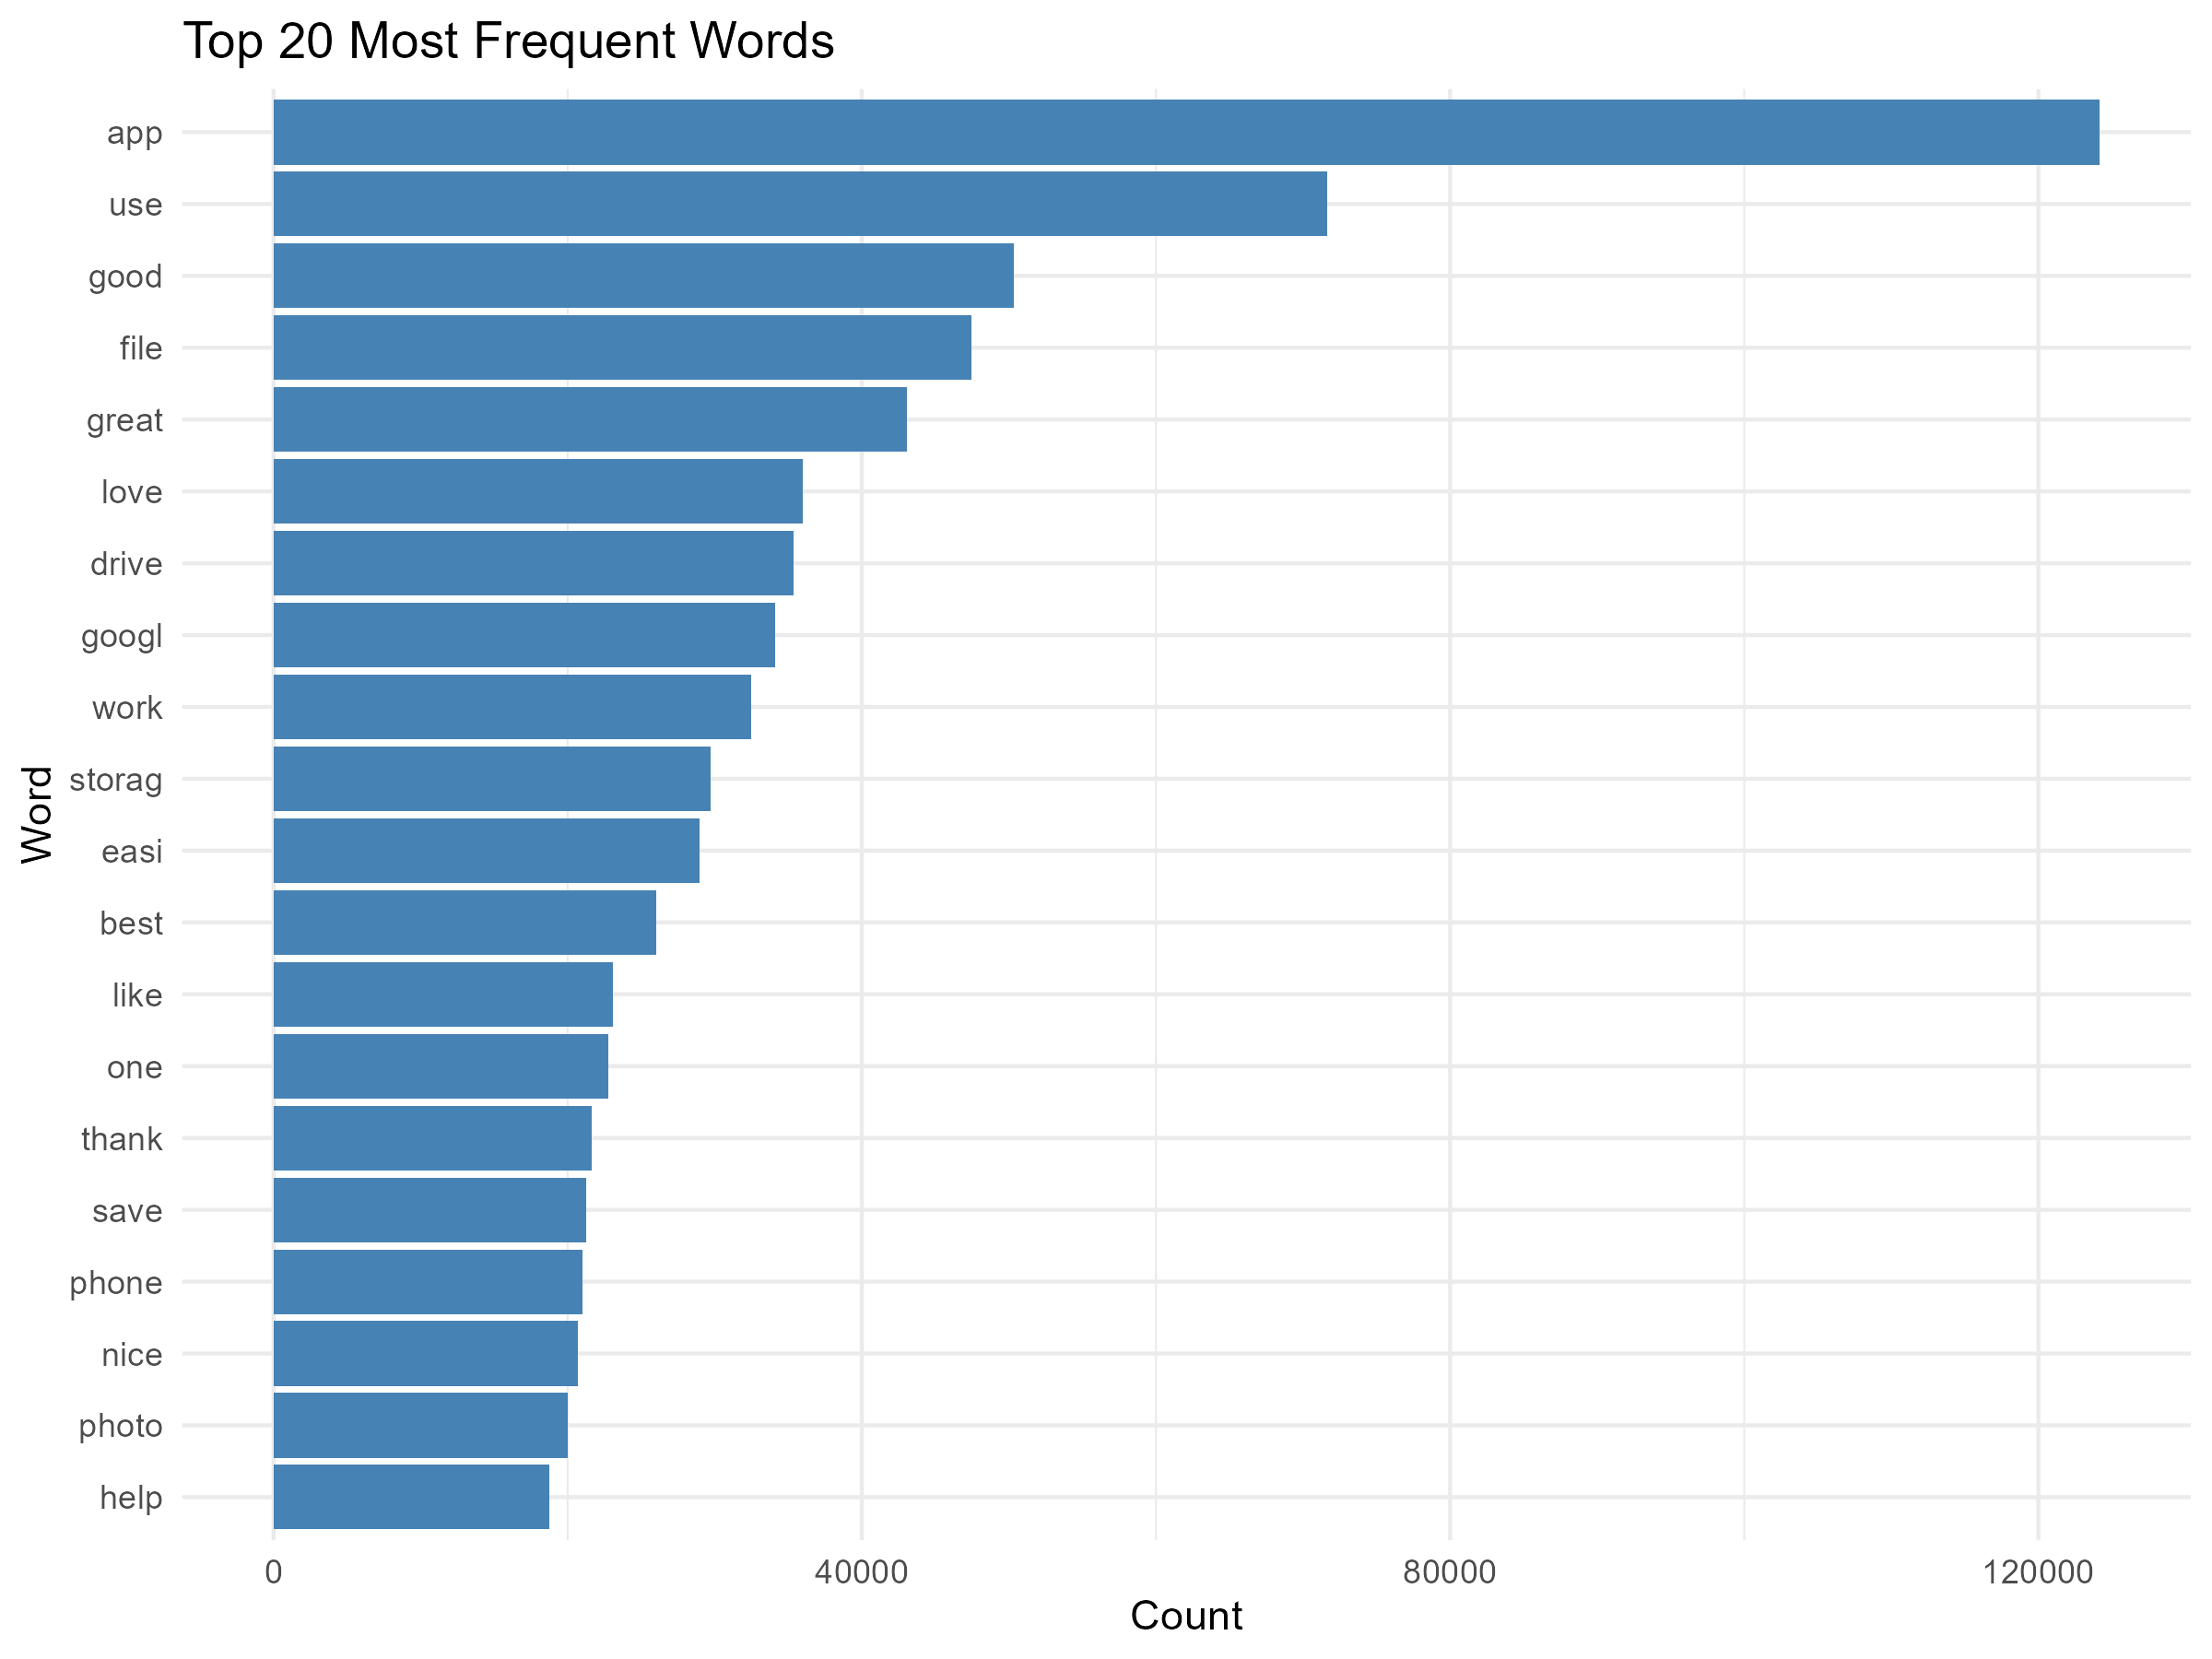
##4.10 Most Frequent Words (Top-20) – Positive Reviews

**Files:**  
- `top20_words.csv`  
- `graph_top20_words.png`  

| Word | Count | Word | Count |
|------|------:|------|------:|
| app | 124,164 | work | 32,504 |
| use | 71,641 | storag | 29,689 |
| good | 50,312 | easi | 28,990 |
| file | 47,464 | best | 26,038 |
| great | 43,074 | like | 23,063 |
| love | 36,001 | one | 22,786 |
| drive | 35,376 | thank | 21,624 |
| googl | 34,081 | save | 21,242 |

---

### Interpretation  

The most frequent words in positive reviews highlight a strong presence of **satisfaction and appreciation-related language**.

### Positive Sentiment Indicators  
Words such as:
- **good**
- **great**
- **love**
- **best**
- **like**
- **thank**
- **nice**
- **help**

clearly indicate that users are expressing **positive experiences, satisfaction, and gratitude** toward the applications.

---

### Functional Usage Words  
A significant portion of frequent terms still relates to application functionality, such as:
- app  
- use  
- file  
- drive  
- google  
- storage  
- save  

These words show that users are mainly discussing **core cloud storage features**, but in a positive context.

---

### Comparison with Negative Reviews  

Unlike negative reviews, positive reviews:
- Do **not contain frustration-driven words** such as *need, fix, delete, error, crash, plea*  
- Are dominated by **approval and usability terms**  
- Show emphasis on **ease of use, reliability, and satisfaction**

---

### Conclusion  

The Top-20 word frequency analysis for positive reviews demonstrates that users primarily express satisfaction with cloud storage applications. The presence of strong positive adjectives combined with functional terms indicates that users appreciate both the usability and performance of these applications.

Overall, the language pattern confirms that positive reviews are centered around **trust, ease of use, and overall satisfaction**, rather than complaints or technical issues.

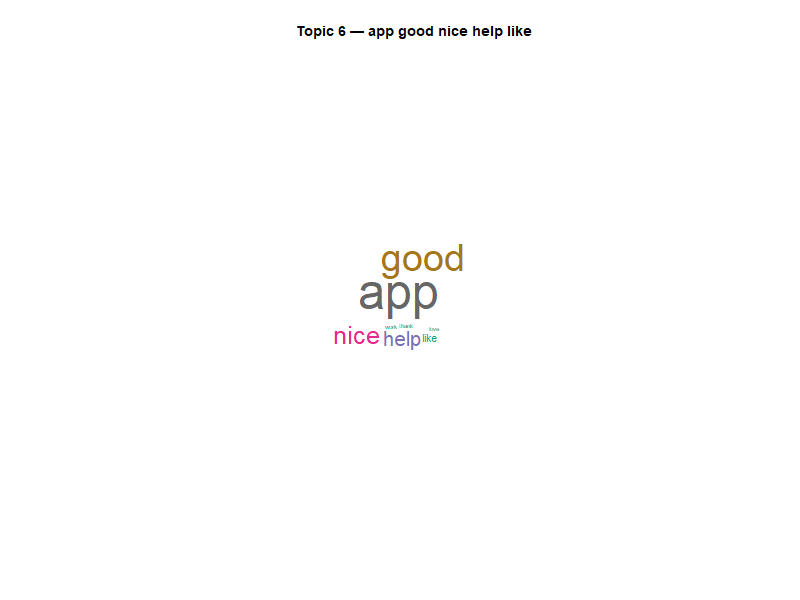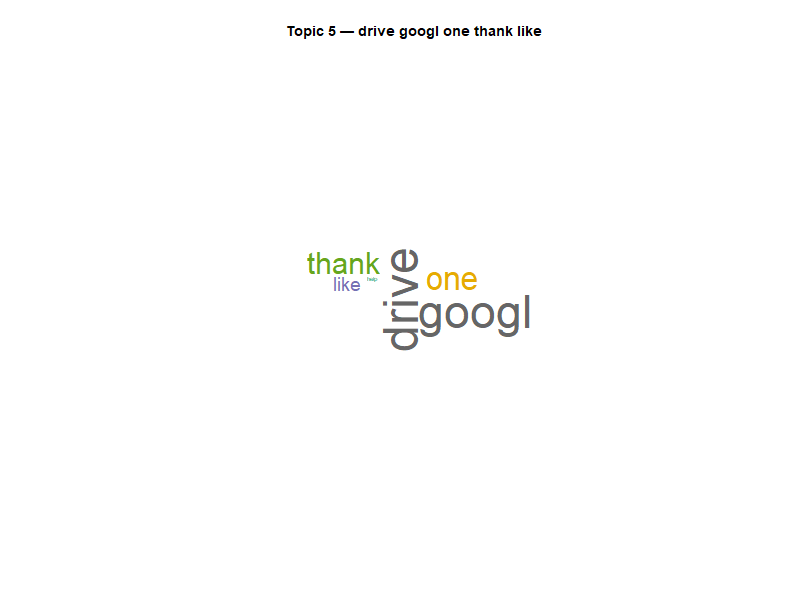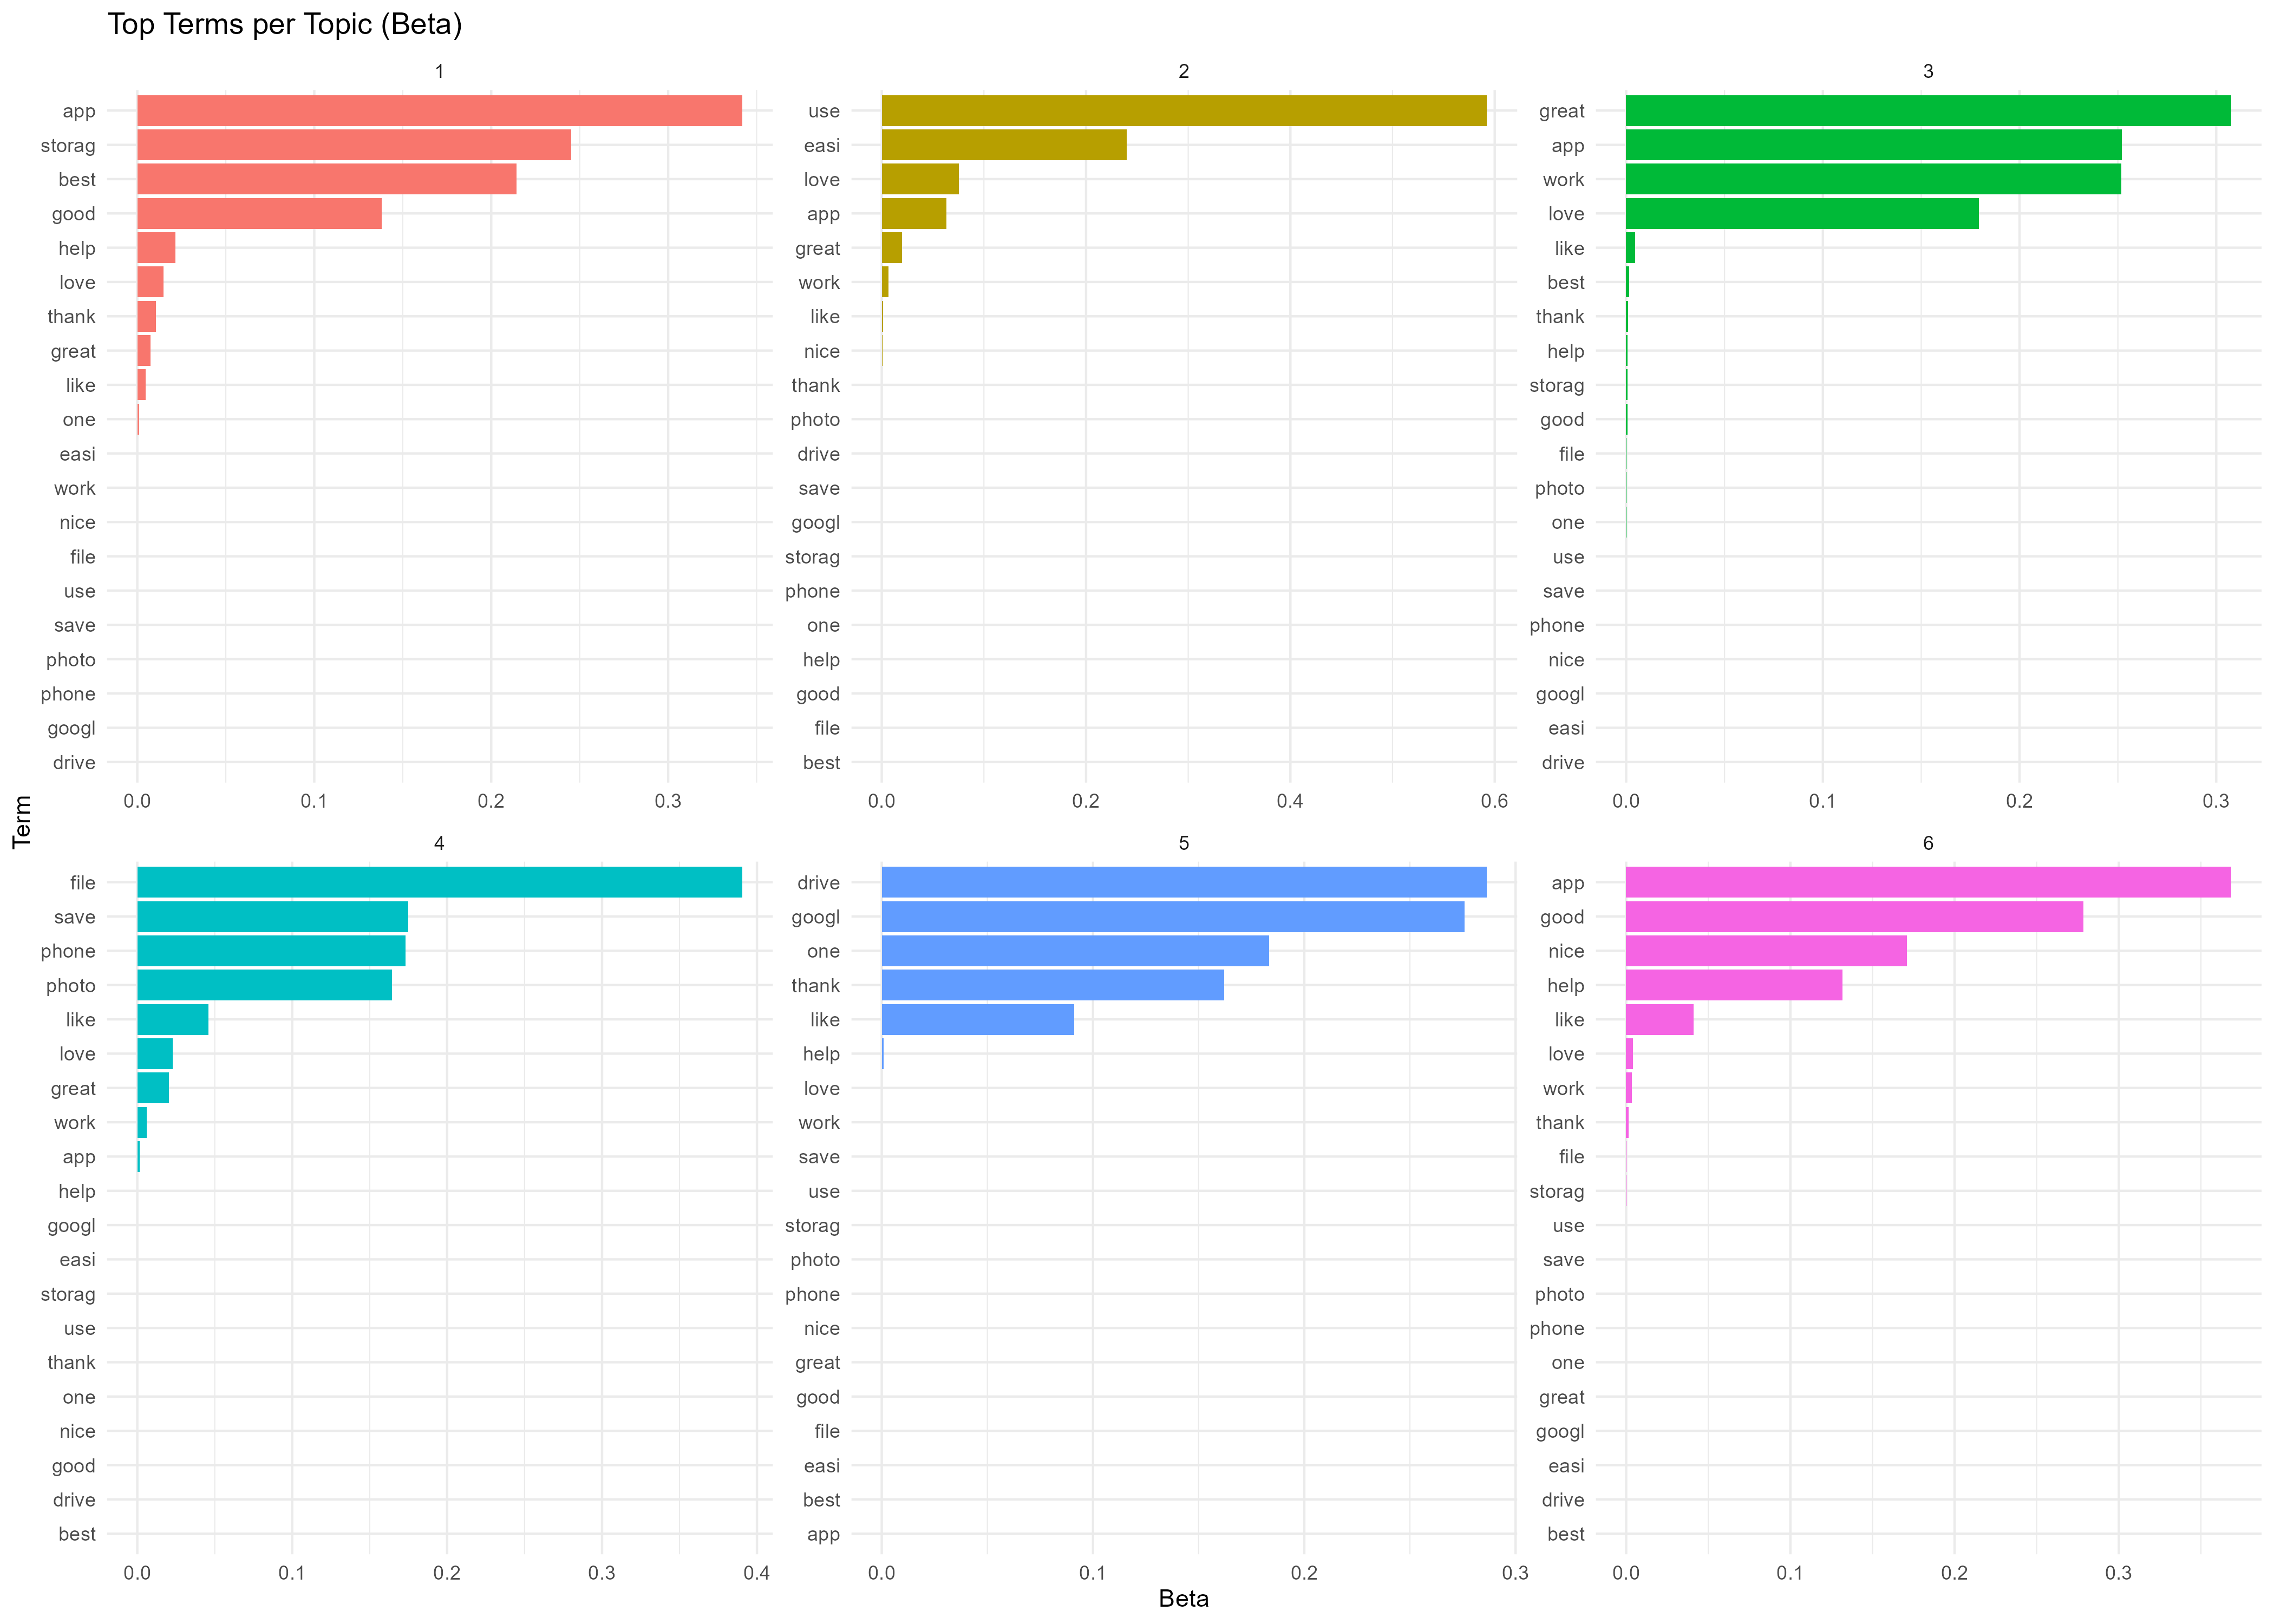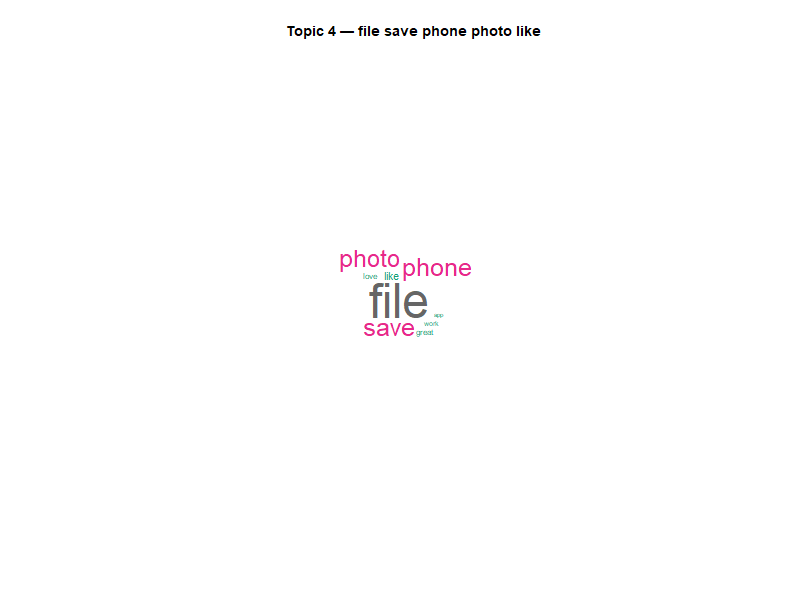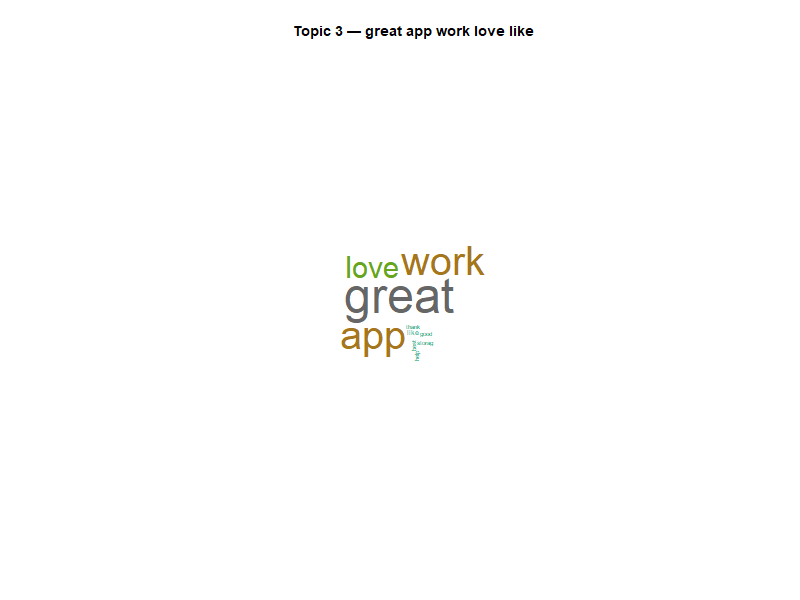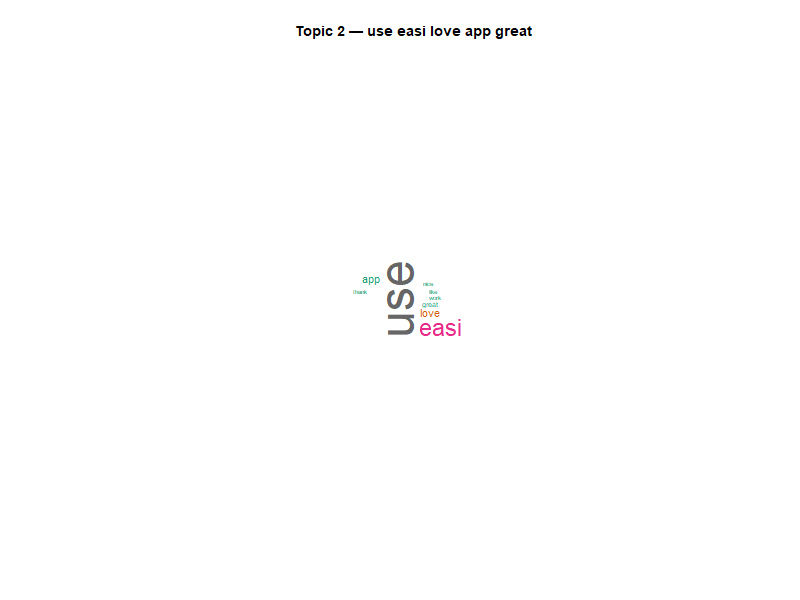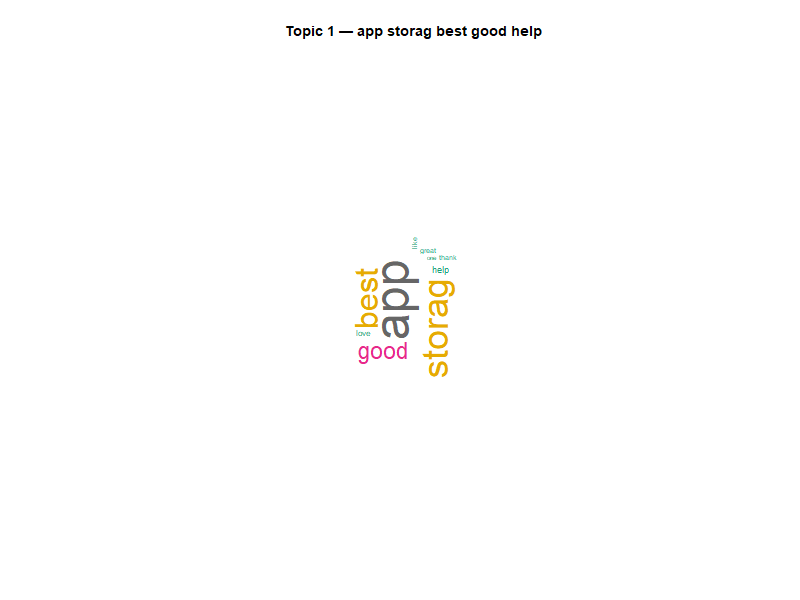

##4.11 Topic Interpretation (Beta Weights) – Positive Reviews

**Files:**  
- `graph_beta_terms.png`  
- `graph_wordcloud_topic1.png` to `graph_wordcloud_topic6.png`  

The table below presents the extracted topics based on beta probabilities from the LDA model. Each topic name is derived from the top 5 most representative stemmed terms, and the interpretation explains what users are praising.

| Topic | Topic Name | Top Beta Terms (Stemmed) | Interpretation (What Users Praise) |
|------|------------|--------------------------|-------------------------------------|
| 1 | app storag best good help | app, storag, best, good, help, free, plan, amount | Users appreciate free storage availability and find the app helpful for managing data. |
| 2 | use easi love app great | use, easi, love, app, great, simpl | Ease of use is a major positive factor; users frequently mention that the app is simple and easy to use. |
| 3 | great app work love like | great, app, work, love, like, good, perfect | General satisfaction with app performance; users express strong approval and positive experience. |
| 4 | file save phone photo like | file, save, phone, photo, like, document, protect | Users praise file and photo saving features, especially backup and protection on mobile devices. |
| 5 | drive googl one thank like | drive, googl, one, thank, like, backup, account | Positive feedback about Google Drive integration, backup features, and account synchronization. |
| 6 | app good nice help like | app, good, nice, help, like, pdf, creat, make | Users highlight usefulness of the app for document creation, PDF handling, and general assistance. |

---

### Key Observation  

Unlike negative review topics, the positive review topics are strongly dominated by **appreciation-oriented vocabulary**, such as:

- love  
- great  
- good  
- nice  
- help  
- thank  
- easy  

There are **no significant complaint-driven terms** such as *fix, error, crash, delete, problem*, which clearly separates positive sentiment themes from negative ones.

---

### Interpretation  

The topic modeling results indicate that users primarily appreciate:

- Ease of use and simple interface  
- Reliable file and photo storage  
- Effective backup and synchronization (especially Google Drive)  
- Overall performance and stability of applications  
- Helpfulness in daily digital tasks (PDFs, documents, saving files)  

Each topic reflects a different dimension of user satisfaction rather than issues or frustrations.

---

### Conclusion  

The Beta-weight topic analysis of positive reviews confirms that users express consistent satisfaction across multiple functional areas of cloud storage applications. The language is dominated by positive emotional and functional terms, indicating strong approval of usability, performance, and reliability.

Overall, the model successfully captures **distinct positive experience themes**, showing that users value simplicity, storage convenience, and dependable cloud synchronization services.

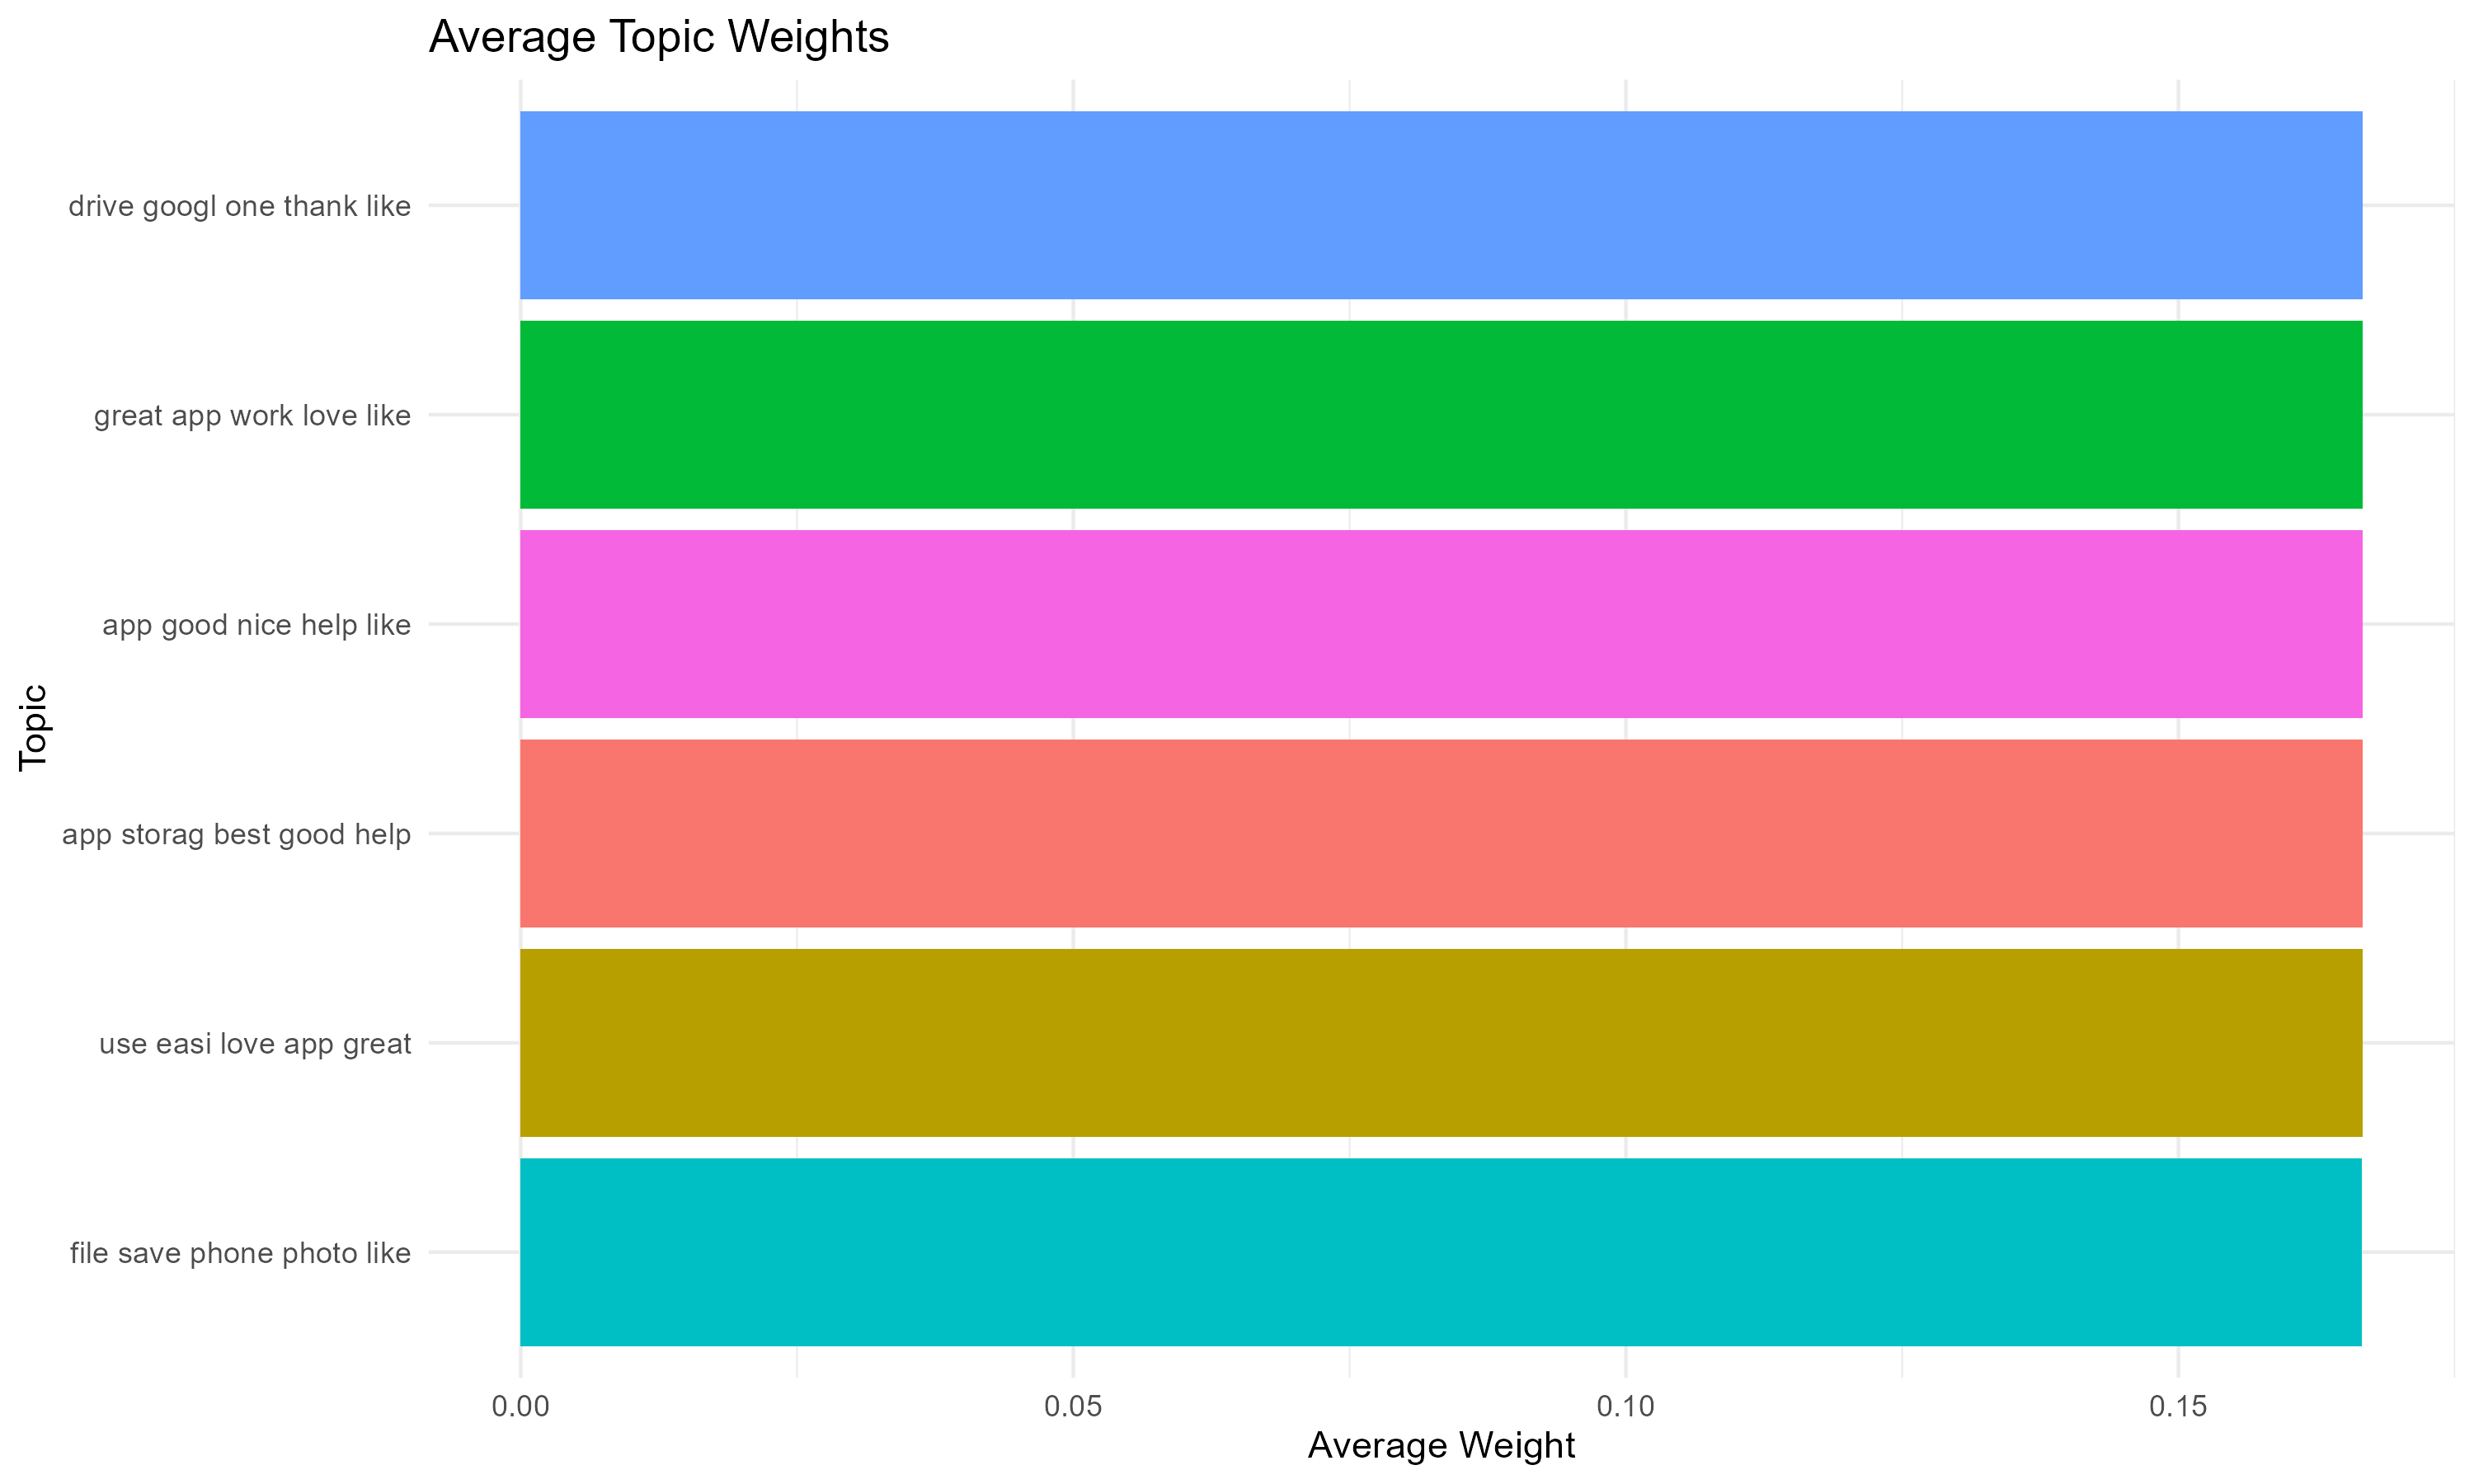
##4.12 Average Topic Weights – Positive Reviews

**Files:**  
- `topic_overall_weights.csv`  
- `graph_topic_weights.png`  

| Topic | Topic Name | AvgWeight |
|------|------------|----------:|
| 1 | app storag best good help | 0.16666 |
| 2 | use easi love app great | 0.16664 |
| 3 | great app work love like | 0.16670 |
| 4 | file save phone photo like | 0.16662 |
| 5 | drive googl one thank like | 0.16670 |
| 6 | app good nice help like | 0.16667 |

---

### Interpretation  

The average topic weights are almost identical across all six topics, each contributing approximately **16.67%** to the overall dataset.

This indicates a highly balanced distribution of positive feedback across all identified themes.

---

### Key Insights  

- All topics carry **nearly equal importance**, showing no single dominant praise category.  
- Users express satisfaction **across multiple features simultaneously**, rather than focusing on one specific aspect.  
- Positive sentiment is evenly distributed among:
  - Storage functionality  
  - Ease of use  
  - File and photo saving  
  - Google Drive integration  
  - General app performance and helpfulness  

---

### Overall Meaning  

Unlike negative reviews where complaints may cluster around specific issues, positive reviews show a **uniform satisfaction pattern**.

This suggests that users:
- Appreciate multiple features equally  
- Do not rely on a single standout feature for satisfaction  
- Experience a generally balanced and well-rounded product performance  

---

### Conclusion  

The average topic weight analysis confirms that positive sentiment is evenly distributed across all identified themes. This indicates that users are broadly satisfied with cloud storage applications, with no single feature dominating their positive experience.

Overall, the results reflect a **consistent and holistic positive user experience** across all functional areas of the applications.

##4.13 Document-Level Topic Assignment (Sample from Positive Data)

**File Generated:**  
- `topic_weights_per_document.csv`  

The following examples show how individual positive reviews are assigned to their dominant LDA topics. Each review is classified based on the highest probability topic from the model.

| Review Text (Shortened) | Dominant Topic | Dominant Topic Name | Why? |
|------|------|------|------|
| love simpl app nice amount storag even free plan | Topic 1 | app storag best good help | Mentions “storage” and “free plan”, strongly aligned with Topic 1 (storage praise). |
| found app save document even chang miss phone | Topic 4 | file save phone photo like | Focuses on saving documents and phone-related functionality. |
| goggl drive instal updat problem take care android | Topic 4 | file save phone photo like | Despite mentioning issues, overall context relates to file/phone usage. |
| omg guy liter live without googl drive keep photo | Topic 2 | use easi love app great | Expresses ease of use and strong positive sentiment toward usability. |
| seem use applic | Topic 2 | use easi love app great | Generic usage statement mapped to ease-of-use theme. |
| thank lot best app | Topic 1 | app storag best good help | Strong positive sentiment with “best app” and appreciation. |
| storag expans app | Topic 1 | app storag best good help | Direct reference to storage functionality. |
| like save dcmt protect viru | Topic 4 | file save phone photo like | Focus on saving documents and protection features. |
| realli helpur app | Topic 3 | great app work love like | General appreciation without specific feature mention. |
| alway good experi | Topic 6 | app good nice help like | General satisfaction and positive experience. |
| googl drive basic digit junk drawer never find need | Topic 5 | drive googl one thank like | Direct reference to Google Drive usage and storage organization. |
| thank opportun hope account well set alway | Topic 5 | drive googl one thank like | Expresses gratitude and account-related experience. |
| open googl drive | Topic 5 | drive googl one thank like | Direct mention of Google Drive usage. |
| bhen di aa ta mai ba school download kit eh app | Topic 1 | app storag best good help | Despite informal language, indicates app download/storage usage. |
| thank ad drive backup download star thnx | Topic 5 | drive googl one thank like | Mentions backup, drive, and appreciation. |
| best app googl drive | Topic 1 (tie with 5) | app storag best good help | Mixed signals between “best app” and Google Drive mention. |
| app help u make file pdf nice app creat pdf | Topic 6 | app good nice help like | Focus on helpful features like PDF creation. |
| good enough gb individu free storag | Topic 1 | app storag best good help | Highlights free storage availability. |
| help app go back old work save stuff print | Topic 1 | app storag best good help | Mentions saving and recovering work. |

---

### Key Observation  

Even in positive reviews, the model sometimes assigns topics based on **dominant functional context rather than isolated emotional words**.

For example:
- Reviews containing minor issues or mixed wording are still classified into positive themes if overall context is positive.
- Words like *problem* or *miss* do not necessarily shift sentiment assignment if the review structure remains appreciative.

---

### Interpretation  

The LDA model focuses on **contextual meaning rather than individual words**, meaning:

- Positive reviews with technical terms are still grouped under satisfaction themes  
- Ease-of-use and storage-related topics dominate classification  
- Google Drive-related mentions are strongly linked to backup and file management themes  
- General praise often maps to broad “app quality” topics  

---

### Conclusion  

The document-level topic assignment confirms that positive reviews are consistently grouped into meaningful satisfaction themes. Even when reviews include mixed language or minor negative expressions, the overall topic classification reflects the dominant positive context.

This demonstrates that topic modeling effectively captures **semantic structure and user intent**, rather than relying only on surface-level word sentiment.

#5 Conclusion & Recommendations (Combined: Negative + Positive)

## 5.1 Summary of Findings – Side by Side

| Aspect | Negative Reviews (Problems) | Positive Reviews (Strengths) |
|-------|----------------------------|------------------------------|
| Top sentiment words | need, even, plea, fix, delete, still, problem | love, great, good, best, thank, nice, help |
| Storage | Users complain about storage running out, need to delete photos/files | Users praise free storage, “enough GB”, helpful storage management |
| Ease of Use | No explicit ease-of-use praise – instead *even* (disappointment) | easi, love app great – ease of use is a major strength |
| Updates | Major complaint – after update app crashes, doesn’t work, users plead for fix | No update-related praise (neutral/absent) |
| Upload / Download | Slow uploads, downloads fail, “still trying”, error messages | No strong praise – users assume it works well |
| File / Photo saving | Photo deletion anxiety – “delete want space”, “phone storage full” | Users like saving files/photos, protection from viruses |
| Google Drive sync | Mixed – issues with account sync, authentication | Users thank for Drive backup, integration works well for many |
| Helpfulness | Users say “plea fix”, “need help” (frustration) | Users say “helpful app”, “nice help” |
| Topic weight distribution | Equal (all problems equally important) | Equal (all strengths equally appreciated) |

---

### 5.2 Key Conclusions

### 🔴 From Negative Reviews (What’s Broken)

- **Update failures**: After updates, the app crashes, stops working, or doesn’t open. Users frequently request fixes.  
- **Upload/download bottlenecks**: Uploads are slow, often stuck (“still trying”), and downloads fail without clear resolution.  
- **Photo deletion panic**: Users are forced to delete photos to free space, indicating weak storage optimization.  
- **Storage anxiety**: Even with free plans, users feel storage is insufficient and lack proper cleanup tools.  
- **Google Drive sync issues**: Authentication and syncing problems lead to inconsistent file access.

---

### 🟢 From Positive Reviews (What Works Well)

- **Ease of use**: Users consistently find the app simple and easy to use.  
- **Free storage offering**: Many users appreciate free GBs and consider them sufficient.  
- **File/document saving**: Strong appreciation for secure storage and document handling.  
- **Helpfulness**: Users describe the app as useful for everyday file and photo management.  
- **Google Drive integration**: Backup and accessibility features are widely appreciated.

---

### 🟡 Surprising / Contrasting Insights

- **Update experience gap**: Positive reviews rarely mention updates, while negative reviews strongly criticize them — suggesting inconsistent update experience across users.  
- **Storage perception difference**: Positive users feel storage is sufficient, while negative users feel constant shortage — indicating different usage levels.  
- **Help vs plea contradiction**: The same concept “help” appears differently:
  - Positive: “helpful app”  
  - Negative: “please help fix”  

---

### 5.3 Actionable Recommendations

### 🚨 High Priority (Critical Fixes)

| Problem | Recommendation | Expected Impact |
|---------|---------------|----------------|
| Update crashes | Implement staged rollouts + auto-rollback if crash rate > threshold. Add crash reporting feature | Reduce major 1-star update complaints |
| Upload failures | Add resume upload, background queue, and clearer error messages | Improve reliability perception |
| Photo deletion anxiety | Introduce “free up device space only” feature with undo option | Improve user retention |
| Storage full issues | Add storage manager + proactive cleanup suggestions | Reduce frustration and uninstall risk |
| Google Drive sync issues | Improve authentication stability + add manual sync button | Increase trust and consistency |

---

### ✅ Medium Priority (Enhance Strengths)

| Strength | Recommendation |
|----------|---------------|
| Ease of use | Maintain simple UI; keep advanced features hidden |
| Free storage | Highlight free storage more prominently; consider loyalty rewards |
| File/photo protection | Add visible security/virus scan indicators |
| Helpfulness | Add in-app guided support and smart help suggestions |

---

### 🔮 Long-Term Strategic Recommendations

- **Controlled update system**: Optional update channels with stability focus  
- **Personalized storage plans**: Recommend storage based on user behavior  
- **Sentiment monitoring system**: Track keywords like *fix, even, plea* for early issue detection  
- **User retention strategy**: Convert “ease of use” users into loyal users by fixing reliability issues  

---

### 5.4 Final Verdict

The application demonstrates strong core strengths in usability, storage utility, and user satisfaction. However, technical instability—especially update failures, upload issues, and storage limitations—is significantly impacting user experience.

These issues are the primary reason for negative sentiment, despite strong appreciation from other users.

---

## Final One-Line Insight

> **“The product is highly loved, but reliability issues are preventing it from reaching its full potential.”**

## 🔗 Connect With Authors
### 👨‍💻 Muhammad Salman Saleem
<div id="badges">
  <a href="https://www.linkedin.com/in/muhammadsalman010/">
    <img src="https://img.shields.io/badge/LinkedIn-blue?style=for-the-badge&logo=linkedin&logoColor=white"/>
  </a>

  <a href="https://web.facebook.com/zzalman0/">
    <img src="https://img.shields.io/badge/Facebook-blue?style=for-the-badge&logo=facebook&logoColor=white"/>
  </a>

  <a href="https://www.kaggle.com/zzalman">
    <img src="https://img.shields.io/badge/Kaggle-blue?style=for-the-badge&logo=kaggle&logoColor=white"/>
  </a>

  <a href="https://github.com/zzalman">
    <img src="https://img.shields.io/badge/GitHub-black?style=for-the-badge&logo=github&logoColor=white"/>
  </a>

  <a href="https://www.instagram.com/zzalman0/">
    <img src="https://img.shields.io/badge/Instagram-purple?style=for-the-badge&logo=instagram&logoColor=white"/>
  </a>

  <a href="mailto:salman793440@gmail.com">
    <img src="https://img.shields.io/badge/Email-red?style=for-the-badge&logo=gmail&logoColor=white"/>
  </a>
</div>


### 👩‍💻 Amna Nawaz Gondal
<div id="badges">
  <a href="https://www.linkedin.com/in/amna-nawaz-245633352?utm_source=share_via&utm_content=profile&utm_medium=member_ios">
    <img src="https://img.shields.io/badge/LinkedIn-blue?style=for-the-badge&logo=linkedin&logoColor=white"/>
  </a>

  <a href="https://github.com/amnanawaz28">
    <img src="https://img.shields.io/badge/GitHub-black?style=for-the-badge&logo=github&logoColor=white"/>
  </a>

  <a href="https://www.instagram.com/aamnaunfiltered__">
    <img src="https://img.shields.io/badge/Instagram-purple?style=for-the-badge&logo=instagram&logoColor=white"/>
  </a>

  <a href="mailto:Amnanawazgondal28@gmail.com">
    <img src="https://img.shields.io/badge/Email-red?style=for-the-badge&logo=gmail&logoColor=white"/>
  </a>
</div>

---


### 👨‍💻 Muhammad Ahsan Shahzad
<div id="badges">
  <a href="https://www.linkedin.com/in/muhammad-ahsan-shahzad-31a207271?utm_source=share_via&utm_content=profile&utm_medium=member_android">
    <img src="https://img.shields.io/badge/LinkedIn-blue?style=for-the-badge&logo=linkedin&logoColor=white"/>
  </a>

  <a href="https://www.facebook.com/share/18hmuQBAHt/">
    <img src="https://img.shields.io/badge/Facebook-blue?style=for-the-badge&logo=facebook&logoColor=white"/>
  </a>

  <a href="https://github.com/Ahsanjutt099">
    <img src="https://img.shields.io/badge/GitHub-black?style=for-the-badge&logo=github&logoColor=white"/>
  </a>

  <a href="https://www.instagram.com/ahsan_jutt_104?igsh=ajdkcm1vMGcxbDU1">
    <img src="https://img.shields.io/badge/Instagram-purple?style=for-the-badge&logo=instagram&logoColor=white"/>
  </a>

  <a href="mailto:muhammadahsan104ml@gmail.com">
    <img src="https://img.shields.io/badge/Email-red?style=for-the-badge&logo=gmail&logoColor=white"/>
  </a>
</div>